# Model Calibration

**Basic notebook setup: Add directories to path, import basic jax and set to 64-bit precision, set up plotting**

In [1]:
import sys
import os
import jax
import jax.numpy as np
import jax.tree as jtu
import jax.random as jr
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Basic jax import
jax.config.update("jax_enable_x64", True)
# os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
# os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.9"


# Check if running on remote, and set directory to where notebook is run
if jax.devices()[0].platform == "gpu":
    os.chdir("code/amigo_project/notebooks/calibration")

# Add parent directories
paths = [os.path.abspath(os.path.join(os.getcwd(), path)) for path in ['..', "../.."]]
for path in paths:
    if path not in sys.path:
        sys.path.insert(0, path)

# Plotting set up
%matplotlib inline
plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 120

inferno = mpl.colormaps["inferno"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]

inferno.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)


def merge_cbar(ax):
    return make_axes_locatable(ax).append_axes("right", size="5%", pad=0.0)

In [2]:
# Add extra bad pixels
def add_badpix(file):
    file["BADPIX"].data[:1, :] = 1
    file["BADPIX"].data[-1:, :] = 1
    file["BADPIX"].data[:, :1] = 1
    file["BADPIX"].data[:, -1:] = 1
    file["BADPIX"].data[41:43, 1] = 1
    file["BADPIX"].data[58, 67] = 1
    file["BADPIX"].data[43, 0] = 1
    file["BADPIX"].data[44, 70] = 1
    file["BADPIX"].data[4, 45] = 1
    file["BADPIX"].data[58, 14] = 1
    file["BADPIX"].data[61, 54] = 1
    file["BADPIX"].data[51, 27] = 1
    return file


def file_stats(file):
    # Get only the secondary dither position
    header = file["PRIMARY"].header
    r = np.hypot(header["XOFFSET"], header["YOFFSET"])
    im = np.array(file["SLOPE"].data, dtype=float).sum(axis=0)
    badpix = np.array(file["BADPIX"].data, dtype=float)
    im = im.at[badpix == 1].set(np.nan)
    n_photons = header["NINTS"] * np.nansum(im) / 1e6

    # Remove TD-CAL for star names
    if "TD-CAL-" in header["TARGPROP"]:
        header["TARGPROP"] = header["TARGPROP"].replace("TD-CAL-", "")
    return r, im, n_photons

In [3]:
from astropy.io import fits


val_files = []

print("COMM1903")
program_path = "/Volumes/morgana2/snert/max/data/JWST/1093/calslope"
# program_path = "../../data/calslope/COMM1903"

for fname in os.listdir(program_path):
    if "DS_Store" in fname:
        continue
    file_path = os.path.join(program_path, fname)
    file = add_badpix(fits.open(file_path))
    r, im, n_photons = file_stats(file)

    header = file["PRIMARY"].header
    conds = (
        header["IS_PSF"],
        header["PATTTYPE"] == "NONE",
        header["NUMDTHPT"] == 1,
        header["TARGPROP"] == "HD-36805",
        r > 1,
    )

    if all(conds):
        val_files.append(file)
        print(
            header["FILTER"],
            f"{n_photons:.0f}",
            header["NGROUPS"],
            f"{np.nanmax(im)/1e3:.1f}",
            header["TARGPROP"],
        )

print()
print("GO1843")
program_path = "/Volumes/morgana2/snert/max/data/JWST/1843/calslope"
# program_path = "../../data/calslope/GO1843"

for fname in os.listdir(program_path):
    if "DS_Store" in fname:
        continue
    file_path = os.path.join(program_path, fname)
    file = add_badpix(fits.open(file_path))
    r, im, n_photons = file_stats(file)

    header = file["PRIMARY"].header
    conds = (
        header["IS_PSF"],
        header["PATTTYPE"] == "NONE",
        header["NUMDTHPT"] == 1,
    )

    if all(conds):
        val_files.append(file)

        print(
            header["FILTER"],
            f"{n_photons:.0f}",
            header["NGROUPS"],
            f"{np.nanmax(im)/1e3:.1f}",
            header["TARGPROP"],
        )

print()
print("GTO1242")
program_path = "/Volumes/morgana2/snert/max/data/JWST/1242/calslope"
# program_path = "../../data/calslope/GTO1242"
for fname in os.listdir(program_path):
    if "DS_Store" in fname:
        continue
    file_path = os.path.join(program_path, fname)
    file = add_badpix(fits.open(file_path))
    r, im, n_photons = file_stats(file)

    header = file["PRIMARY"].header
    conds = (
        header["IS_PSF"],
        n_photons > 1000,
        header["FILTER"] != "F277W",
        header["TARGPROP"] != "HD-101531",
    )

    if all(conds):
        val_files.append(file)
        print(
            header["FILTER"],
            f"{n_photons:.0f}",
            header["NGROUPS"],
            f"{np.nanmax(im)/1e3:.1f}",
            header["TARGPROP"],
        )

# print()
# fnames = set([f[0].header["FILENAME"] for f in val_files])
# program_path = "../../data/calslope/calibrators"
# # program_path = "../../data/calslope/calibrators"
# for fname in os.listdir(program_path):
#     if "DS_Store" in fname:
#         continue
#     file_path = os.path.join(program_path, fname)
#     file = add_badpix(fits.open(file_path))
#     r, im, n_photons = file_stats(file)

#     header = file["PRIMARY"].header
#     conds = (
#         header["IS_PSF"],
#         n_photons > 1000,
#         header["FILTER"] not in ["F277W"],
#         header["FILENAME"] not in fnames,
#         header["TARGPROP"] in ["HD-116084"],
#     )

#     if all(conds):
#         val_files.append(file)
#         print(
#             header["FILTER"],
#             f"{n_photons:.0f}",
#             header["NGROUPS"],
#             f"{np.nanmax(im)/1e3:.1f}",
#             header["TARGPROP"],
#         )


len(val_files)

COMM1903
F380M 60 3 8.5 HD-36805
F480M 64 9 13.4 HD-36805
F430M 64 6 12.6 HD-36805

GO1843
F480M 536 10 11.7 HD-205827
F380M 2949 3 7.0 HD-205827
F430M 1333 7 11.3 HD-205827

GTO1242
F480M 2441 8 7.1 HD-18638
F430M 2250 5 6.0 HD-18638


8

In [4]:
# from astropy.io import fits
# from amigo.model_fits import FlatFit
# from scripts.load_files import cal_files, val_files, flat_files


program_path = "/Volumes/morgana2/snert/max/data/JWST/4481/calslope"
# program_path = "../../data/calslope/CAL04481"

cal_files = []
for fname in os.listdir(program_path):
    if "DS_Store" in fname:
        continue
    file_path = os.path.join(program_path, fname)
    file = add_badpix(fits.open(file_path))
    cal_files.append(file)
    r, im, n_photons = file_stats(file)

    print(
        header["FILTER"],
        f"{n_photons/1e6:.0f}",
        header["NGROUPS"],
        f"{np.nanmax(im)/1e3:.1f}",
    )


len(cal_files)

F480M 0 5 19.9
F480M 0 5 18.9
F480M 0 5 22.0
F480M 0 5 18.5
F480M 0 5 20.8
F480M 0 5 19.3
F480M 0 5 20.8
F480M 0 5 20.9
F480M 0 5 21.1
F480M 0 5 19.7
F480M 0 5 20.5
F480M 0 5 20.5
F480M 0 5 19.6
F480M 0 5 19.3
F480M 0 5 18.7


15

In [5]:
from amigo.files import get_files

# Get the field files
data_path = "/Volumes/morgana2/snert/max/data/JWST/FLATS/calslope"
# data_path = "../../data/calslope"
flat_files = [add_badpix(f) for f in get_files(f"{data_path}/", "nis_calslope")]

_flat_files = []
for file in flat_files:
    if file[0].header["NGROUPS"] == 45:
        print("Skipping")
        continue
    _flat_files.append(file)
flat_files = _flat_files

Skipping


In [6]:
# bp = np.load("../../amigo/src/amigo/data/badpix.npy")
bp = np.load("/Users/mc/code/amigo/src/amigo/data/badpix.npy")

#
badpix = np.zeros((80, 80))
for file in flat_files:
    badpix = np.array(file["BADPIX"].data)
    badpix += badpix.astype(int)

#
badpix = ~(badpix == 0)
full_badpix = badpix | bp


def add_bpix(file):
    badpix = np.array(file["BADPIX"].data, dtype=bool)
    badpix = badpix.at[29, 69].set(True)
    badpix = badpix.at[49, 74].set(True)
    badpix = badpix.at[61, 52].set(True)
    badpix = badpix.at[53, 18].set(True)
    file["BADPIX"].data = (badpix | full_badpix).astype(int)
    return file

In [7]:
file.info()

Filename: /Volumes/morgana2/snert/max/data/JWST/FLATS/calslope/flat_F480M_30_nis_calslope.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     218   ()      
  1  RAMP          1 ImageHDU         9   (80, 80, 30)   float32   
  2  RAMP_COV      1 ImageHDU        10   (80, 80, 30, 30)   float32   
  3  RAMP_SUP      1 ImageHDU         9   (80, 80, 30)   int32   
  4  SLOPE         1 ImageHDU         9   (80, 80, 29)   float32   
  5  SLOPE_COV     1 ImageHDU        10   (80, 80, 29, 29)   float32   
  6  SLOPE_SUP     1 ImageHDU         9   (80, 80, 29)   int32   
  7  BADPIX        1 ImageHDU         8   (80, 80)   int32   
  8  ASDF          1 BinTableHDU     11   1R x 1C   [7253B]   


In [8]:
from amigo.model_fits import PointFit, FlatFit

# Construct the exposures
flat_exposures = [FlatFit(add_bpix(file)) for file in flat_files]
cal_exposures = [PointFit(add_bpix(file)) for file in cal_files]
val_exposures = [PointFit(add_bpix(file)) for file in val_files]
exposures = cal_exposures + flat_exposures + val_exposures

# exposures = []
# for exp in _exposures:
#     badpix = exp.badpix
#     badpix = badpix.at[29, 69].set(True)
#     badpix = badpix.at[49, 74].set(True)
#     badpix = badpix.at[61, 52].set(True)
#     badpix = badpix.at[53, 18].set(True)
#     exposures.append(exp.set(["badpix", "support"], [badpix, np.where(~badpix)]))


files = cal_files + val_files + flat_files
[f.close() for f in files]

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [9]:
import equinox as eqx
import zodiax as zdx
import jax.nn as nn
import dLux.utils as dlu
from jax import vmap
from amigo.core_models import NNWrapper
from amigo.ramp_models import get_spatial_kernels
import dLux.utils.geometry as geo


def calc_gradient(pt1, pt2):
    return dlu.nandiv((pt2[1] - pt1[1]), (pt2[0] - pt1[0]))


def calc_dist(coords, m, pt, softness):
    return geo.soften(geo.line_distance(coords, m, pt), softness, invert=True)


def calc_oversampled_kernel(coords, ms, pts, softness):
    dist_fn = lambda m, pt: calc_dist(coords, m, pt, softness)
    return vmap(dist_fn)(ms, pts).min(0)


def kernel_from_pts(coords, ms, pts, softness, osamp):
    dist_fn = lambda m, pt: calc_dist(coords, m, pt, softness)
    osamp_kernel = vmap(dist_fn)(ms, pts).min(0)
    return dlu.downsample(osamp_kernel, osamp, mean=True)


def calc_kernel(idx, shifts, coords, osamp, softness):
    i, j = idx

    # Add the relative corner positions to the shifts
    pt1 = np.array([-0.5, -0.5]) + shifts[:, i + 0, j + 0]
    pt2 = np.array([-0.5, +0.5]) + shifts[:, i + 1, j + 0]
    pt3 = np.array([+0.5, +0.5]) + shifts[:, i + 1, j + 1]
    pt4 = np.array([+0.5, -0.5]) + shifts[:, i + 0, j + 1]

    points = np.array([pt1, pt2, pt3, pt4])
    edges = np.array([(pt1, pt2), (pt2, pt3), (pt3, pt4), (pt4, pt1)])
    ms = vmap(lambda pts: calc_gradient(*pts))(edges)
    return kernel_from_pts(coords, ms, points, softness, osamp)


class KernelModel(zdx.Base):
    softness: float
    osamp: int = eqx.field(static=True)
    coords: jax.Array
    spatial_encoder: eqx.nn.Conv2d
    bleed_encoder: NNWrapper

    def __init__(self, key=jr.key(0), calc_osamp=3, softness=0.1):

        self.osamp = calc_osamp
        self.softness = softness
        self.coords = dlu.pixel_coords(9 * self.osamp, 3)

        # Default convolutional layers
        def Conv2d(in_channels=1, out_channels=1, key=None):
            return eqx.nn.Conv2d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=3,
                padding=1,
                key=key,
                use_bias=False,
            )

        def ConvT2d(in_channels=1, key=None):
            return eqx.nn.ConvTranspose2d(
                in_channels=in_channels,
                out_channels=2,
                kernel_size=2,
                stride=2,
                use_bias=False,
                key=key,
            )

        spatial_encoder = Conv2d(1, 16, jr.key(0))  # dummy key
        kernels = np.array(jtu.leaves(get_spatial_kernels()))[:, None]
        self.spatial_encoder = eqx.tree_at(
            lambda conv: conv.weight, spatial_encoder, kernels
        )

        # Convolution layers: Feature extraction from charge/bias distribution
        keys = jr.split(key, 3)
        conv_layers = [
            # Encode spatial features
            Conv2d(16, 16, keys[0]),
            # ReLU activation, get some non linearity
            eqx.nn.Lambda(nn.relu),
            # Learn relationship between spatial features
            Conv2d(16, 2, keys[1]),
            # # ReLu here?
            # # eqx.nn.Lambda(nn.relu),
            # # Transposed conv to predict upsample 2x per pixel (shift of each corner)
            # ConvT2d(16, key=keys[2]),
            # # Average the corner shift from each pixel
            # eqx.nn.AvgPool2d(kernel_size=2, stride=2, padding=-1),
            # Tanh to limit the shifts to +-0.5
            eqx.nn.Lambda(lambda x: 0.33 * nn.tanh(x)),
            # Padding layer to fill the outer edge pixel shifts
            eqx.nn.Lambda(lambda x: np.pad(x, ((0, 0), (1, 1), (1, 1)))),
        ]

        self.bleed_encoder = NNWrapper(eqx.nn.Sequential(conv_layers))

    def __getattr__(self, key):
        if hasattr(self.bleed_encoder, key):
            return getattr(self.bleed_encoder, key)
        raise AttributeError(f"KernelModel has no attribute {key}")

    def calc_kernels(self, npix, shifts):
        calc_fn = lambda idx: calc_kernel(
            idx, shifts, self.coords, self.osamp, self.softness
        )
        indices = np.indices((npix, npix)).reshape(2, -1)
        return vmap(calc_fn, -1, -1)(indices).reshape(9, 9, npix, npix)

    def predict_kernels(self, charge):
        """Predict spatially adaptive transposed convolution kernels."""
        # Get the spatial features
        spatial_features = self.spatial_encoder(charge[None])  # (16, 80, 80)

        # mask = np.ones(16).at[0].set(0)
        # spatial_features *= mask[:, None, None]

        # plt.figure(figsize=(20, 16))
        # for i in range(16):
        #     plt.subplot(4, 4, i + 1)
        #     plt.imshow(spatial_features[i], origin="lower")
        #     plt.colorbar()
        # plt.show()

        # Predict the pixel positional shifts for each corner
        shifts = self.bleed_encoder(spatial_features)  # (2, 81, 81)

        # plt.hist(shifts.flatten(), bins=100)
        # plt.yscale("log")
        # plt.show()

        # Calculate the kernel for each pixel
        npix = charge.shape[0]
        return self.calc_kernels(npix, shifts)
        # # calc_fn = lambda idx: calc_kernel(idx, shifts, self.coords, self.osamp, self.softness)
        # indices = np.indices((npix, npix)).reshape(2, -1)
        # return vmap(calc_fn, -1, -1)(indices).reshape(9, 9, npix, npix)

    def __call__(self, charge):
        return self.predict_kernels(charge)


kernel_model = KernelModel()

In [10]:
import equinox as eqx
import zodiax as zdx
from jax.lax import dynamic_slice as dyn_slice
from amigo.core_models import NNWrapper
from amigo.misc import interp_ramp
from amigo.ramp_models import calc_kernels, apply_kernels_stride
from amigo.ramp_models import PixelSensitivity
from amigo.ramp_models import fill_array, overlap_fn


def array_to_kernels(array, npix, k_size):
    reshaped = array.reshape(npix, k_size, npix, k_size)
    return np.transpose(reshaped, (1, 3, 0, 2))


def kernels_to_array(kernels):
    k_size, _, npix, _ = kernels.shape
    permuted = np.transpose(kernels, (2, 0, 3, 1))
    return permuted.reshape(npix * k_size, npix * k_size)


def calc_kernels(coords, sensitivity):
    # coords shape: (2, k_size, k_size, npix, npix)
    shape = coords.shape
    oversample, npix = shape[1], shape[-1]
    full_coords = vmap(kernels_to_array)(coords)

    # Create an empty coordinates array to pad
    empty_coords = np.tile(dlu.pixel_coords(3, 1), (npix + 2, npix + 2))
    padded = vmap(fill_array)(empty_coords, full_coords)

    # Define the convolution function
    k_size = 3  # Hard set the kernel size for now
    n = k_size * oversample  # (9, 9)

    # TODO: Cache this guy?
    rel_cen = dlu.pixel_coords(3, 3)

    # Sensitivity is a 2D array of shape (npix * ksize, npix * ksize)
    n_pad = sensitivity.shape[0] + 2 * k_size
    ones = np.ones((n_pad, n_pad))
    padded_sens = ones.at[k_size:-k_size, k_size:-k_size].set(sensitivity)

    def kern_fn(i, j):
        coords_window = dyn_slice(padded, (0, i, j), (2, n, n))
        coords_kerns = vmap(array_to_kernels, (0, None, None))(coords_window, 3, k_size)
        box_coord_kerns = coords_kerns + rel_cen[:, None, None, ...]
        box_coords = vmap(kernels_to_array)(box_coord_kerns)
        box_coords_vec = box_coords.reshape(2, -1).T
        fractions = vmap(overlap_fn)(box_coords_vec).reshape(n, n)
        return fractions * dyn_slice(padded_sens, (i, j), (n, n))

    # Apply the convolution
    indices = k_size * np.indices((npix, npix)).reshape(2, -1)
    kernels_vec = vmap(kern_fn, out_axes=-1)(*indices)
    return kernels_vec.reshape(n, n, npix, npix)


class NNKernelModel(zdx.Base):
    knots: jax.Array
    spatial_encoder: dict
    bleed_encoder: NNWrapper

    def __init__(self, key=jr.key(0)):
        self.knots = dlu.pixel_coords(3, 1)

        # Default convolutional layers
        def Conv2d(in_channels=1, out_channels=1):
            return lambda key: eqx.nn.Conv2d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=3,
                padding=1,
                key=key,
                use_bias=False,
            )

        # Default convolutional layers
        def ConvTranspose2d(in_channels=1, out_channels=1):
            return lambda key: eqx.nn.ConvTranspose2d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=3,
                stride=3,
                padding=0,
                use_bias=False,
                key=key,
            )

        key, subkey = jr.split(key, 2)
        spatial_encoder = Conv2d(in_channels=1, out_channels=16)(subkey)
        kernels = np.array(jtu.leaves(get_spatial_kernels()))[:, None]
        self.spatial_encoder = eqx.tree_at(
            lambda conv: conv.weight, spatial_encoder, kernels
        )

        # Convolution layers: Feature extraction from charge/bias distribution
        conv_layers = [
            Conv2d(in_channels=16, out_channels=16),
            Conv2d(in_channels=16, out_channels=16),
            ConvTranspose2d(in_channels=16, out_channels=2),
        ]

        # Initialize them with keys, and add relu activation
        keys = jr.split(key, len(conv_layers))
        layers = []
        for i, layer in enumerate(conv_layers):
            layers.append(layer(keys[i]))
            if i < len(conv_layers) - 1:
                layers.append(eqx.nn.Lambda(nn.relu))
        layers.append(eqx.nn.Lambda(lambda x: 0.5 * nn.tanh(x)))

        # Construct the encoder
        self.bleed_encoder = NNWrapper(eqx.nn.Sequential(layers))

    def __getattr__(self, key):
        if hasattr(self.bleed_encoder, key):
            return getattr(self.bleed_encoder, key)
        raise AttributeError(f"KernelModel has no attribute {key}")

    def predict_shifts(self, relative_charge):
        """Predict spatially adaptive transposed convolution kernels."""
        # Get the spatial features
        spatial_features = self.spatial_encoder(relative_charge[None])  # (16, 80, 80)

        # Predict the pixel positional shifts
        shifts = self.bleed_encoder(spatial_features)  # (2, 240, 240)

        # Ouptut shape # (2, 3, 3, 80, 80)
        npix = relative_charge.shape[0]
        return vmap(array_to_kernels, (0, None, None))(shifts, npix, 3)

    def predict_coords(self, relative_charge):
        """Predict spatially adaptive transposed convolution kernels."""
        shifts = self.predict_shifts(relative_charge)
        return shifts + self.knots[..., None, None]

    def predict_kernels(self, relative_charge, sensitivity):
        """Predict spatially adaptive transposed convolution kernels."""
        coords = self.predict_coords(relative_charge)
        return calc_kernels(coords, sensitivity)

    def __call__(self, relative_charge, sensitivity):
        return self.predict_kernels(relative_charge, sensitivity)

In [11]:
from amigo.optical_models import gen_powers, distort_coords


class PolyKernelModel(zdx.Base):
    knots: jax.Array
    powers: jax.Array
    spatial_encoder: eqx.nn.Conv2d
    bleed_encoder: NNWrapper

    def __init__(self, key=jr.key(0)):
        self.knots = dlu.pixel_coords(3, 1)

        # Coordinate distortion set up
        self.knots = dlu.pixel_coords(3, 1)
        self.powers = np.array(gen_powers(3))
        n_features = np.array(self.powers).size

        # Default convolutional layers
        def Conv2d(in_channels=1, out_channels=1, key=jr.key(0)):
            return eqx.nn.Conv2d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=3,
                padding=1,
                key=key,
                use_bias=False,
            )

        # Spatial gradient encoder
        key, subkey = jr.split(key, 2)
        kernels = np.array(jtu.leaves(get_spatial_kernels()))[:, None]
        spatial_encoder = Conv2d(in_channels=1, out_channels=16, key=subkey)
        spatial_encoder = eqx.tree_at(
            lambda conv: conv.weight, spatial_encoder, kernels
        )
        layers = [eqx.nn.Lambda(lambda x: x[None]), spatial_encoder]
        self.spatial_encoder = eqx.nn.Sequential(layers)

        # Convolution layers: Feature extraction from charge/bias distribution
        keys = jr.split(key, 3)
        layers = [
            Conv2d(in_channels=16, out_channels=16, key=keys[0]),
            eqx.nn.Lambda(nn.relu),
            Conv2d(in_channels=16, out_channels=16, key=keys[1]),
            eqx.nn.Lambda(nn.relu),
            Conv2d(in_channels=16, out_channels=16, key=keys[1]),
            eqx.nn.Lambda(nn.relu),
            Conv2d(in_channels=16, out_channels=n_features, key=keys[2]),
        ]

        # Construct the encoder
        self.bleed_encoder = NNWrapper(eqx.nn.Sequential(layers))

    def __getattr__(self, key):
        if hasattr(self.bleed_encoder, key):
            return getattr(self.bleed_encoder, key)
        raise AttributeError(f"KernelModel has no attribute {key}")

    def predict_coords(self, charge):
        """Predicts the distorted coordinates."""
        # Predict the distortion coefficients
        spatial_features = self.spatial_encoder(charge)

        # plt.imshow(charge)

        # plt.figure(figsize=(20, 16))
        # for i in range(16):
        #     plt.subplot(4, 4, i + 1)
        #     plt.imshow(spatial_features[i], origin="lower")
        #     plt.colorbar()

        # plt.tight_layout()
        # plt.show()

        coeffs = self.bleed_encoder(spatial_features)
        coeffs_vec = coeffs.reshape(len(coeffs), -1)  # (n_coeffs, 6400)

        # Calculate the distorted coordinates
        distort_fn = lambda coeffs: distort_coords(
            self.knots, coeffs.reshape(self.powers.shape), self.powers
        )
        return vmap(distort_fn, -1, -1)(coeffs_vec).reshape(2, 3, 3, *charge.shape)

    def predict_kernels(self, charge, sensitivity):
        """Predict spatially adaptive transposed convolution kernels."""
        coords = self.predict_coords(charge)
        kernels = calc_kernels(coords, sensitivity)
        return kernels

    def __call__(self, charge, sensitivity):
        return self.predict_kernels(charge, sensitivity)

In [12]:
class NonLinearRamp(zdx.Base):
    """ "Dynamic Filter Recurrent Neural Network (DFRNN) to model charge diffusion and
    bleeding."""

    norm: int
    bleed: bool
    time_steps: int = eqx.field(static=True)
    use_charge: bool
    ff_model: PixelSensitivity
    # kernel_model: NNKernelModel
    kernel_model: PolyKernelModel

    def __init__(
        self,
        key=jr.key(0),
        time_steps=8,
        norm=2**15,
        SRF=0.1,
        use_charge=True,
        bleed=True,
    ):
        self.norm = norm
        self.bleed = bleed
        self.time_steps = time_steps
        self.use_charge = use_charge
        self.kernel_model = PolyKernelModel(key=key)
        self.ff_model = PixelSensitivity(SRF=SRF)

    def __getattr__(self, key):
        if hasattr(self.kernel_model, key):
            return getattr(self.kernel_model, key)
        elif hasattr(self.ff_model, key):
            return getattr(self.ff_model, key)
        raise AttributeError(f"NonLinearRamp has no attribute {key}")

    def predict_kernels(self, charge):
        # NOTE: This is just for visualisation purposes, and preform redundant calcs
        # it should not be used during normal operation
        return self.kernel_model(charge, self.ff_model.sensitivity)
        # return self.kernel_model(charge - np.mean(charge), self.ff_model.sensitivity)

    def predict_coords(self, charge):
        # NOTE: This is just for visualisation purposes, and preform redundant calcs
        # it should not be used during normal operation
        return self.kernel_model(charge, self.ff_model.sensitivity)
        # return self.kernel_model(charge - np.mean(charge), self.ff_model.sensitivity)

    def build_ramp(self, illuminance, charge):
        # Normalise by the time-steps and apply the sensitivity
        illuminance /= self.time_steps
        sensitivity = self.ff_model.sensitivity
        # illuminance *= self.ff_model.sensitivity

        # Dont use the bias if requested
        if not self.use_charge:
            charge = np.zeros_like(charge)

        # Evolve the charge
        charges = [charge]
        if self.bleed:
            for _ in range(self.time_steps):
                # kernels = self.kernel_model(charge - np.mean(charge), sensitivity)
                kernels = self.kernel_model(charge, sensitivity)
                # kernels = self.kernel_model(charge - np.mean(charge))
                # kernels = self.kernel_model(charge)
                charge += apply_kernels_stride(illuminance, kernels)
                charges.append(charge)
        else:
            illum = dlu.downsample(illuminance * sensitivity, 3)
            # illum = dlu.downsample(illuminance, 3)
            charges = [illum for _ in range(self.time_steps)]

        if self.use_charge:
            return np.array(charges)  # + np.median(charge)
        return np.array(charges) + charge  # NOTE THIS IS CURRENTLY BROKEN

    def evolve_illuminance(self, illuminance, charge, ngroups):
        # Normalise the Illuminance and charge
        illuminance = illuminance / self.norm
        charge = charge / self.norm

        # Evolve the charge
        ramp = self.build_ramp(illuminance, charge)
        return self.norm * interp_ramp(ramp, ngroups)

In [13]:
from amigo.core_models import AmigoModel
from amigo.optical_models import AMIOptics
from amigo.detector_models import LinearDetector
from amigo.read_models import ReadModel

# Get the model
model = AmigoModel(
    exposures=exposures,
    optics=AMIOptics(static=False),
    detector=LinearDetector(),
    ramp_model=NonLinearRamp(),
    read=ReadModel(),
)

In [14]:
model.nn_weights.size

8640

In [15]:
slopes = exposures[0](model)

In [16]:
# state = np.load("temp_state.npy", allow_pickle=True).item()

# for key, value in state.items():
#     model = model.set(key, value)

In [17]:
# state = np.load("../../GPU_files/cal_files/cal_model.npy", allow_pickle=True).item()
# state = np.load("final_state.npy", allow_pickle=True).item()
state = np.load(
    "/Volumes/morgana2/snert/max/data/amigo_files/v_0.0.10/calibration.npy",
    allow_pickle=True,
).item()
# state = np.load("new_best_state.npy", allow_pickle=True).item()

# state = np.load("new_best_state.npy", allow_pickle=True).item()
aberrations = {
    key.split("_")[1]: val
    for key, val in state["aberrations"].items()
    if "04481" in key
}

for key, value in state.items():
    if key in [
        "positions",
        "fluxes",
        "aberrations",
        "nn_weights",
        "transmission",
        "badpix",
    ]:
        continue
    model = model.set(key, value)

abb = {}
for key, _ in model.aberrations.items():
    prog, filt = key.split("_")
    abb[key] = state["aberrations"][filt]
    # abb[key] = aberrations[filt]

model = model.set("aberrations", abb)

In [18]:
best_state = np.load(
    "/Volumes/morgana2/snert/max/data/amigo_files/v_0.0.10/calibration.npy",
    allow_pickle=True,
).item()
# best_state = np.load("new_best_state.npy", allow_pickle=True).item()

# _model = model.set("positions", best_state["positions"])
_model = model

# for key, value in best_state.items():
#     _model = _model.set(key, value)

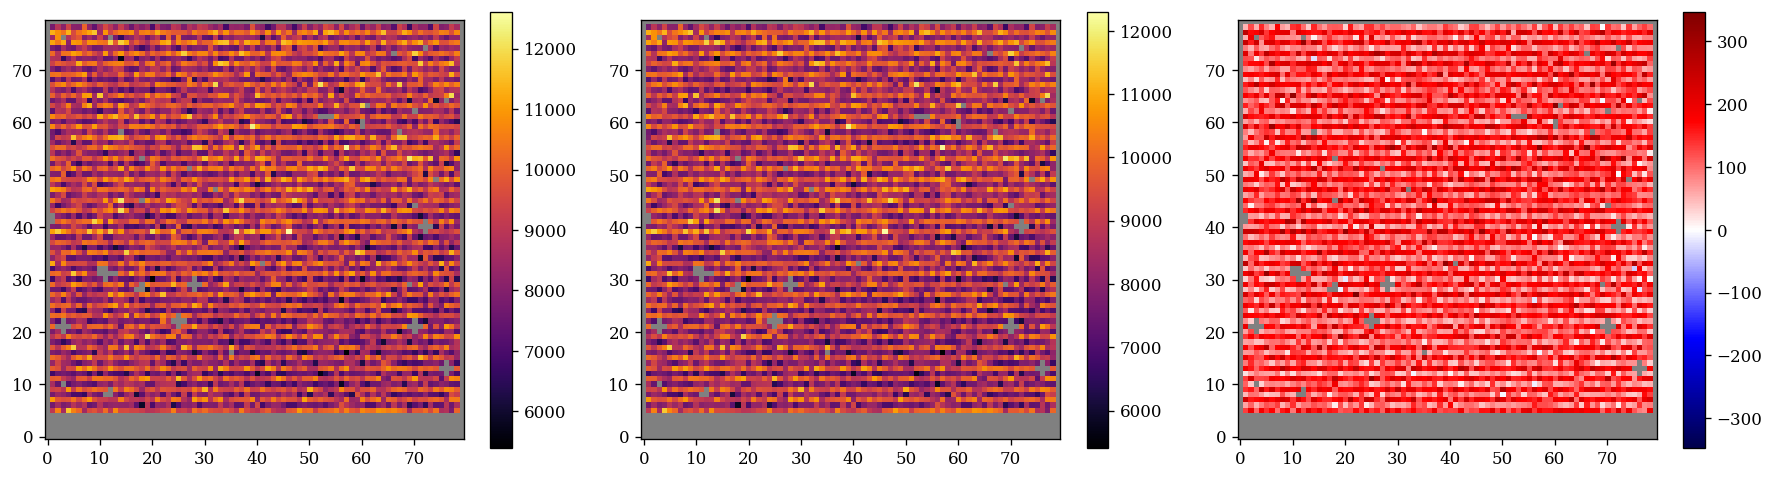

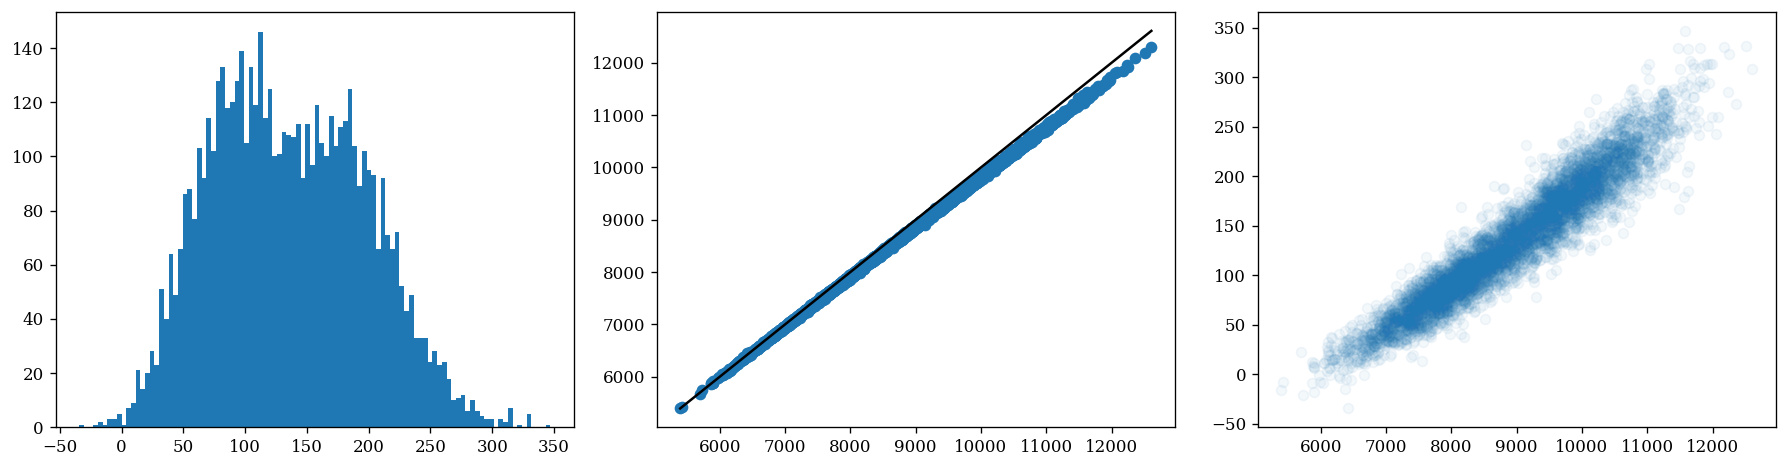

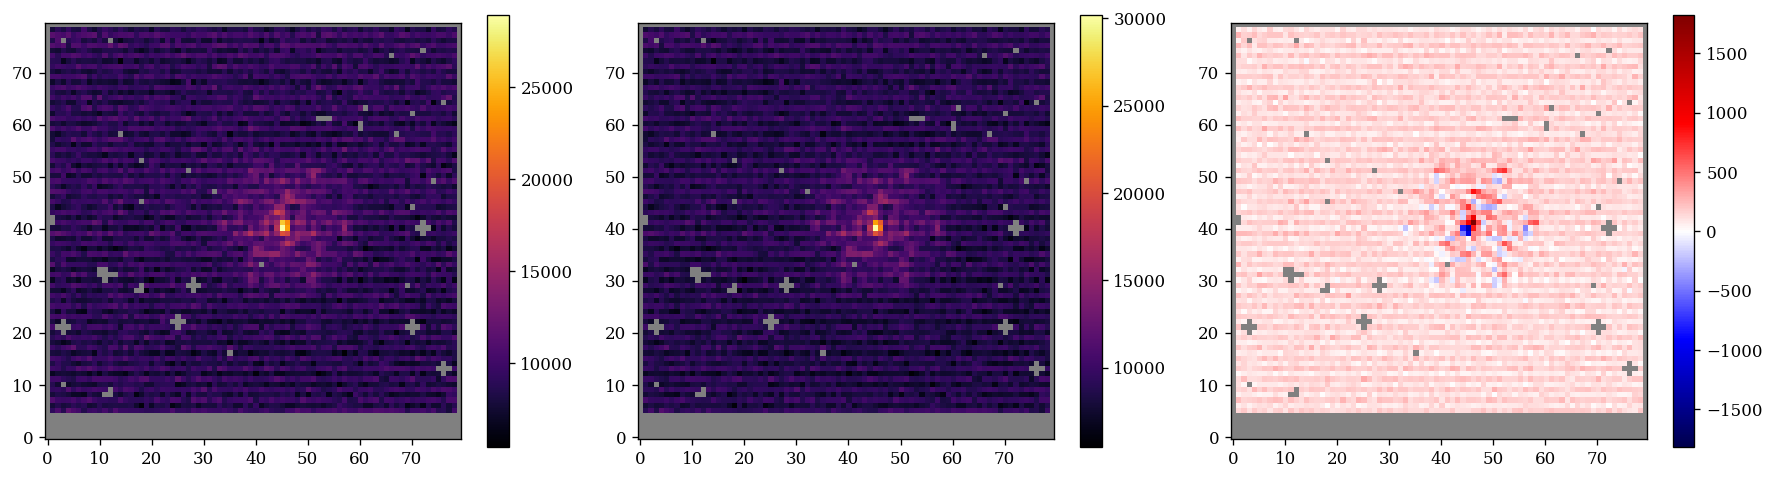

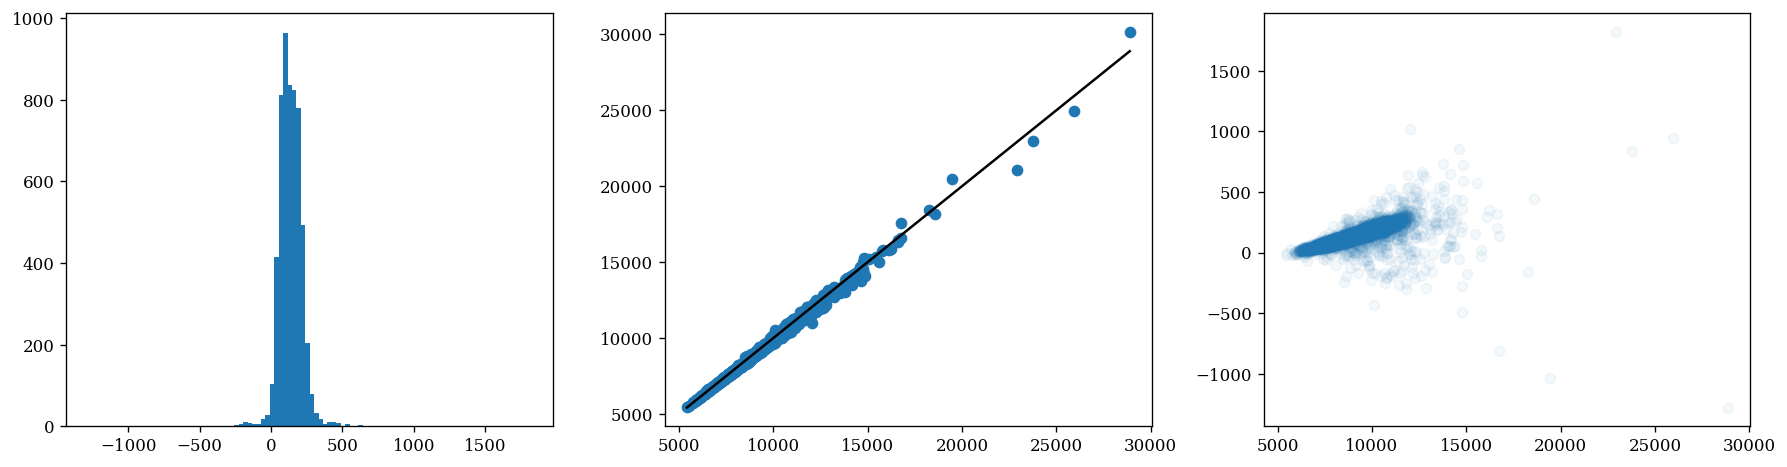

In [19]:
_model = _model.set("gain", model.gain)
# _model = _model.set("gain", 0.01)
# _model = _model.set("gain", 1/1.61)


for exp in cal_exposures:

    for i in [0, -1]:
        # for i in [0]:

        badpix = exp.badpix
        data = np.where(badpix, np.nan, exp.ramp[i])
        ramp = np.where(badpix, np.nan, exp(_model, return_slopes=False)[i])
        res = data - ramp
        v = np.nanmax(np.abs(res))

        plt.figure(figsize=(15, 4))
        plt.subplot(1, 3, 1)
        plt.imshow(data, inferno)
        plt.colorbar()

        plt.subplot(1, 3, 2)
        plt.imshow(ramp, inferno)
        plt.colorbar()

        plt.subplot(1, 3, 3)
        plt.imshow(res, seismic, vmin=-v, vmax=v)
        plt.colorbar()

        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(15, 4))
        plt.subplot(1, 3, 1)
        plt.hist(res.flatten(), bins=100)

        plt.subplot(1, 3, 2)
        plt.scatter(data, ramp)
        xs = np.linspace(np.nanmin(data), np.nanmax(data), 1000)
        plt.plot(xs, xs, c="k")

        plt.subplot(1, 3, 3)
        plt.scatter(data, res, alpha=0.05)

        plt.tight_layout()
        plt.show()
    break

In [20]:
# # Calculate the kernels
# shifts = np.zeros((2, 3, 3, 5, 5))
# sensitivity = np.ones((15, 15))
# # sensitivity = 1 + 0.1 * jr.normal(jr.key(0), (15, 15))
# coords = shifts + dlu.pixel_coords(3, 1)[..., None, None]

# print(coords.shape)

# kernels = calc_kernels(coords, sensitivity)

# print(kernels.shape)
# # # kernels = kernels.T
# # print(kernels.shape)


# plt.figure(figsize=(25 / 2, 20 / 2))
# for i in range(5):
#     for j in range(5):

#         idx = i * 5 + j + 1
#         plt.subplot(5, 5, idx)
#         kern = kernels[..., i, j]
#         plt.title(f"{100 * ((kern.sum() / 9)-1):.3f} %")
#         plt.imshow(kern)
#         plt.colorbar()
# plt.tight_layout()
# plt.show()

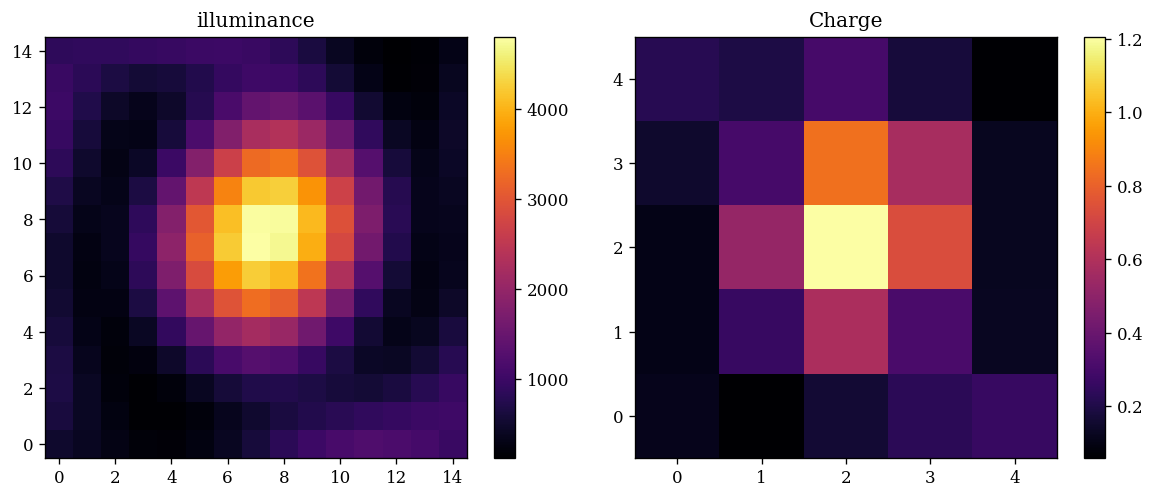

In [21]:
exp = cal_exposures[0]

psf = exp.model_psf(model)
illum = exp.model_illuminance(psf, model).data

ramp_model = model.ramp_model
charge = dlu.downsample(illum, 3, mean=False) / ramp_model.norm

osamp = 3
k_size = 5
k = k_size // 2
ko = (k_size * osamp) // 2
idx = np.where(charge == charge.max())
I, J = idx[0][0], idx[1][0]

Io = I * osamp + 1
Jo = J * osamp + 1

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.title("illuminance")
plt.imshow(illum[Io - ko : Io + ko + 1, Jo - ko : Jo + ko + 1])
plt.colorbar()

plt.subplot(1, 2, 2)
plt.title("Charge")
plt.imshow(charge[I - k : I + k + 1, J - k : J + k + 1])
plt.colorbar()
plt.tight_layout()
plt.show()

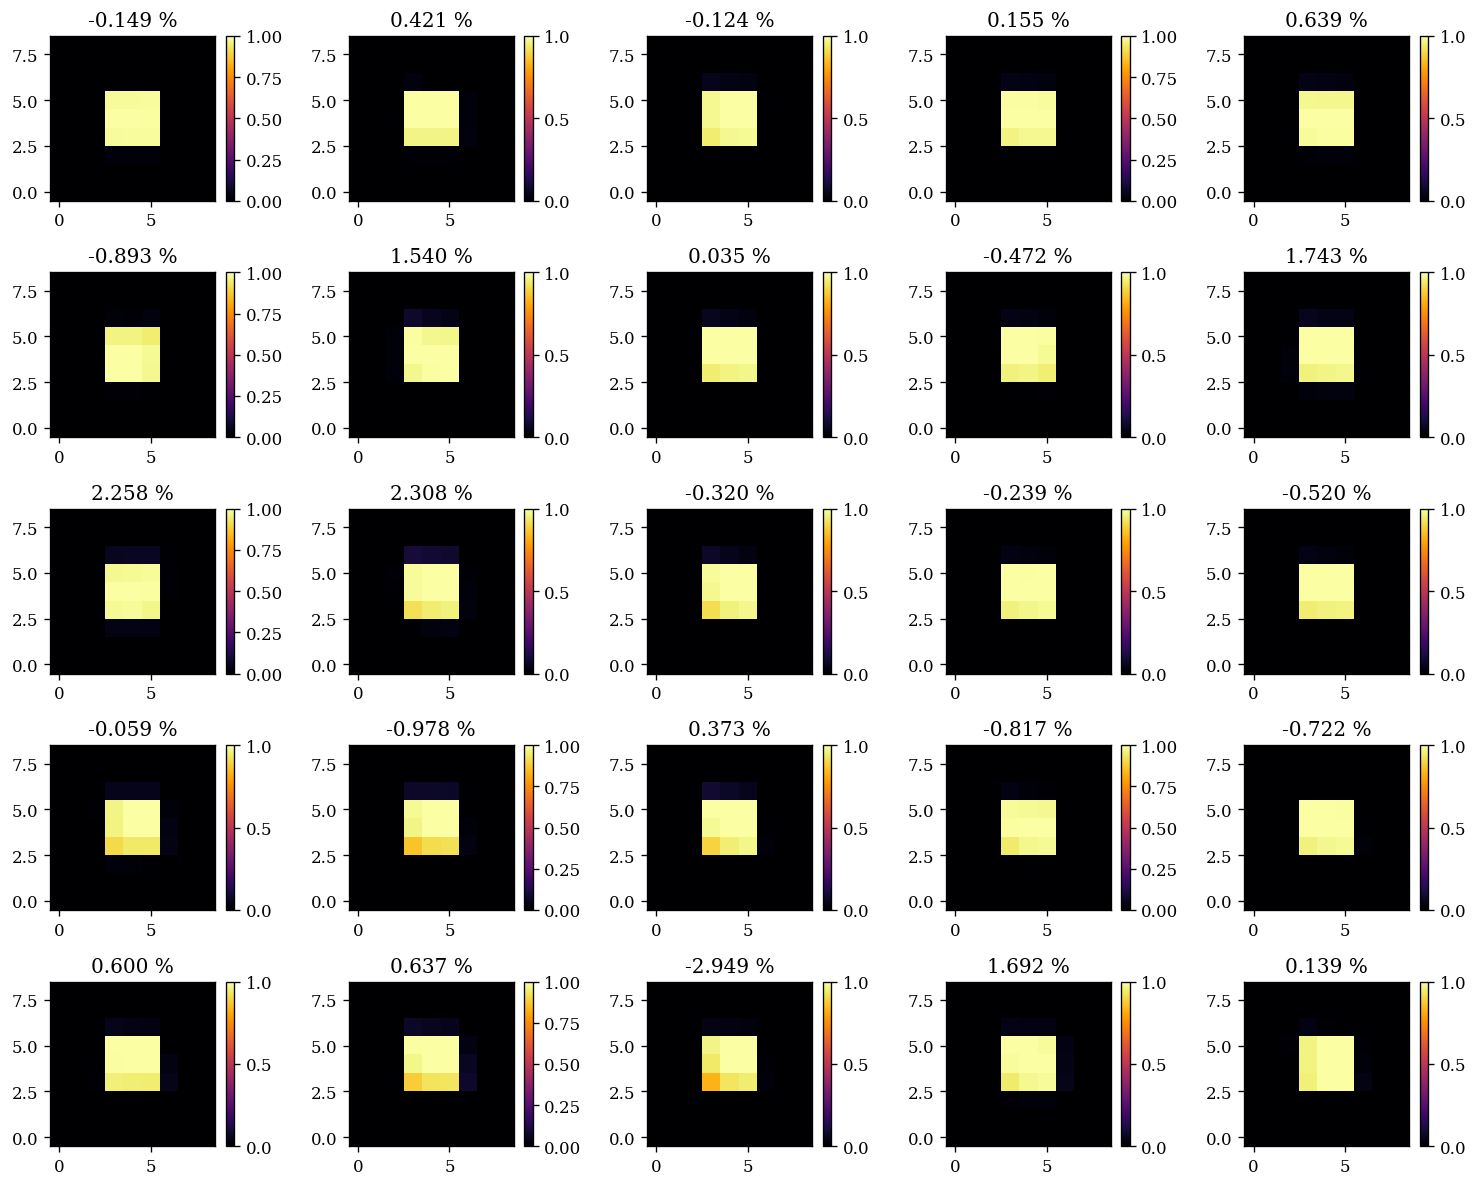

In [22]:
# DFRNN = result.model.ramp.build

charge_in = charge
# sensitivity = 1 + jr.normal(jr.key(0), (240, 240))
# ramp_model = ramp_model.set("FF", 1 +  0.01*jr.normal(jr.key(0), (80, 80)))
# ramp_model = ramp_model.set("FF", 1)
# sensitivity = 1 + 0.1 * jr.normal(jr.key(0), (240, 240))
sensitivity = np.ones((240, 240))
# kernels = ramp_model.kernel_model(charge_in, sensitivity)
kernels = ramp_model.kernel_model.predict_kernels(charge_in, sensitivity)
# coords = ramp_model.kernel_model.predict_coords(charge_in)

# print(coords.shape)

plt.figure(figsize=(25 / 2, 20 / 2))
for i in range(5):
    for j in range(5):
        idx = i * 5 + j + 1
        plt.subplot(5, 5, idx)
        kern = kernels[..., 38 + i, 43 + j]
        plt.title(f"{100 * ((kern.sum() / 9)-1):.3f} %")
        plt.imshow(kern)
        plt.colorbar()
plt.tight_layout()
plt.show()


# plt.figure(figsize=(25 / 2, 20 / 2))
# for i in range(5):
#     for j in range(5):
#         idx = i * 5 + j + 1
#         plt.subplot(5, 5, idx)
#         # kern = kernels[..., 38 + i, 43 + j]
#         # plt.title(f"{100 * ((kern.sum() / 9)-1):.3f} %")
#         plt.scatter(*coords[:, ..., 38 + i, 43 + j])
#         # plt.colorbar()
# plt.tight_layout()
# plt.show()

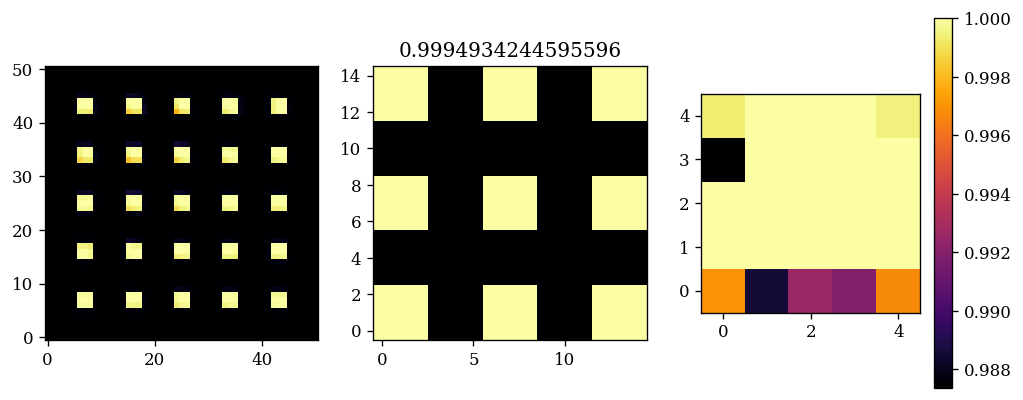

In [23]:
# kern_im = kernels_to_array(kernels[..., 38:43, 43:48].T)
kern_im = kernels_to_array(kernels[..., 38:43, 43:48])
padded = np.pad(kern_im, (3, 3), mode="constant", constant_values=0)

plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1)
plt.imshow(padded)


area_kernel = np.zeros((15, 15))
val = True
for i in range(5):
    for j in range(5):
        area_kernel = area_kernel.at[3 * i : 3 * (i + 1), 3 * j : 3 * (j + 1)].set(val)
        val = not val
area_kernel = area_kernel.at[3:12, 3:12].set(0)
area_kernel = area_kernel.at[6:9, 6:9].set(1)

plt.subplot(1, 3, 2)
plt.imshow(area_kernel)


areas = np.zeros((5, 5))
for i in 9 * np.arange(5):
    for j in 9 * np.arange(5):
        # print(i, j)
        delta = np.zeros((15, 15)).at[6:9, 6:9].set(1)
        influence = area_kernel * padded[i : i + 15, j : j + 15]
        plt.title(influence.sum() / 9)
        area = padded[i : i + 15, j : j + 15] * area_kernel
        areas = areas.at[i // 9, j // 9].set(influence.sum() / 9)

plt.subplot(1, 3, 3)
plt.imshow(areas)
# plt.imshow(areas[1:-1, 1:-1])
plt.colorbar()
plt.show()

F430M


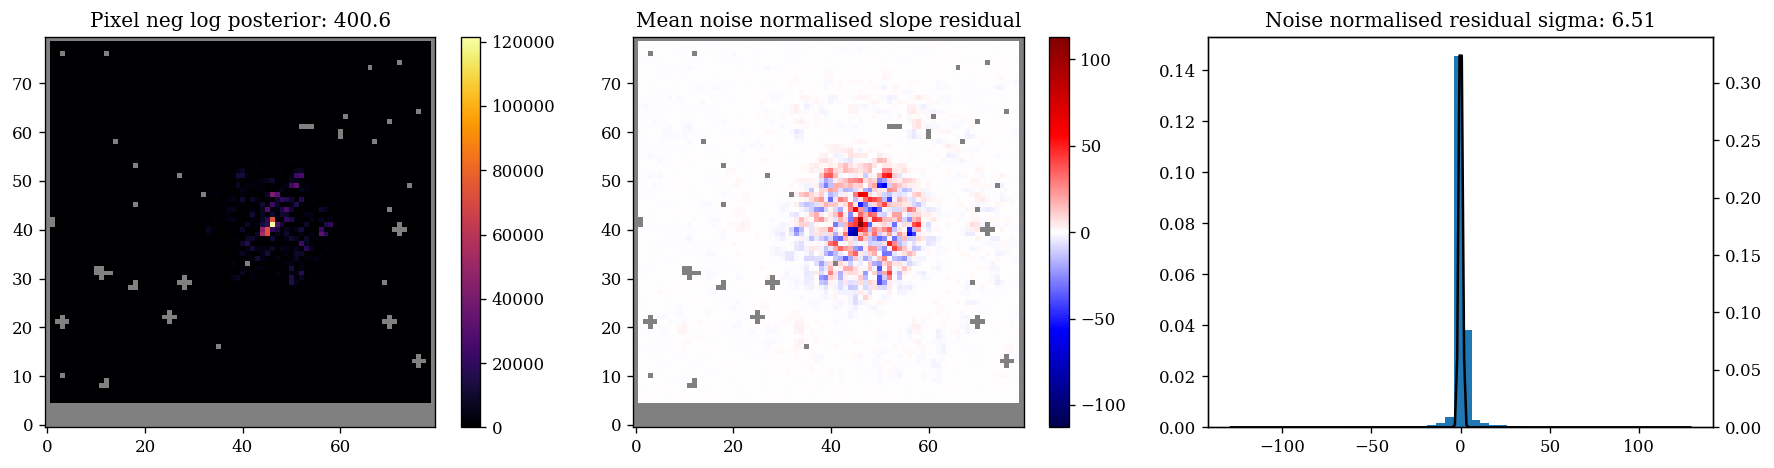

F480M


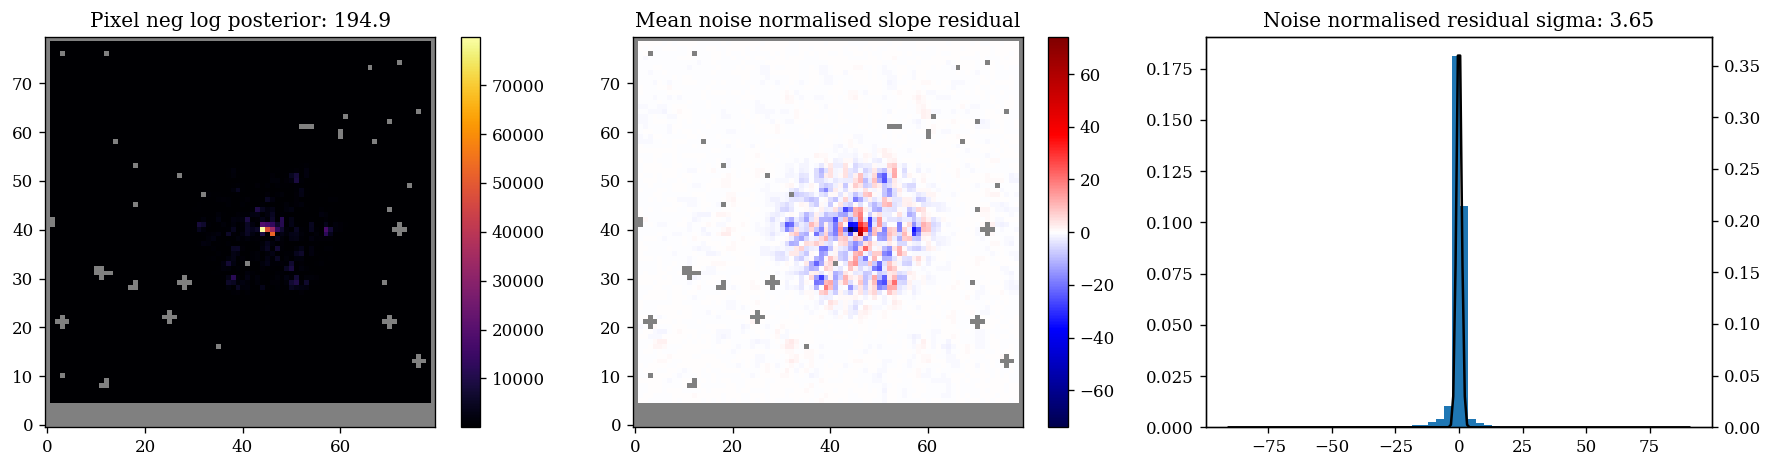

F380M


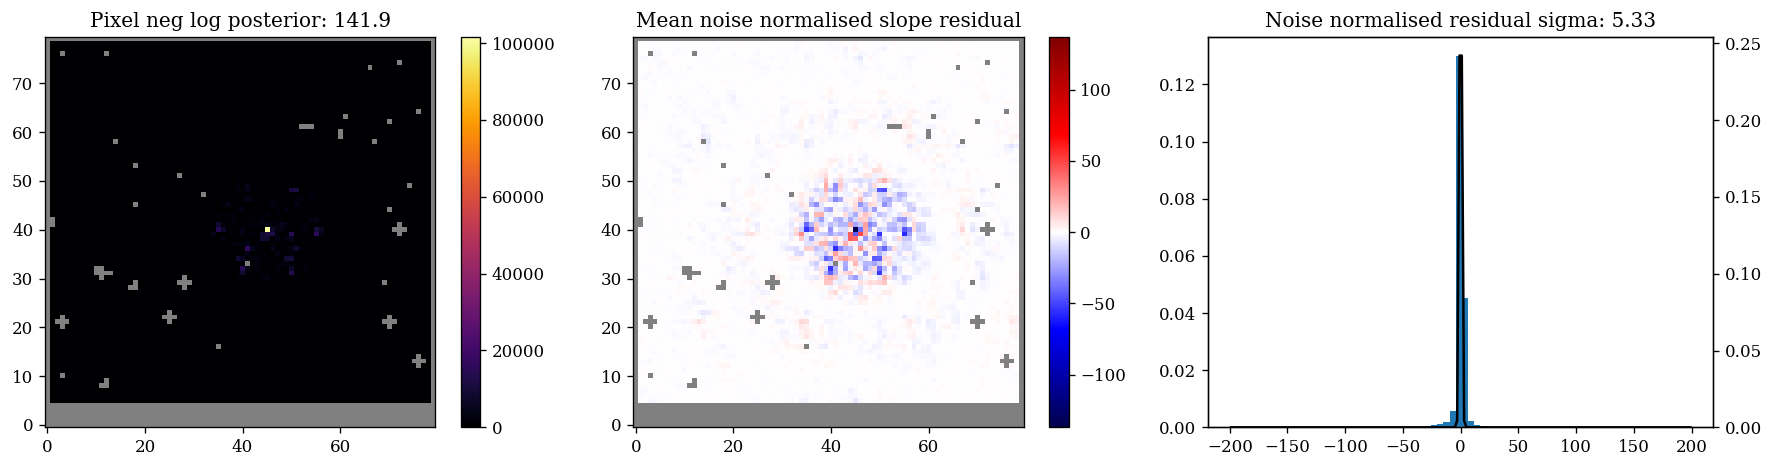

In [24]:
from amigo.plotting import summarise_fit


done = []
for exp in cal_exposures:

    if exp.filter in done:
        continue
    print(exp.filter)
    summarise_fit(model, exp)  # , residuals=True)
    done.append(exp.filter)

01093 F380M HD-36805 3 122


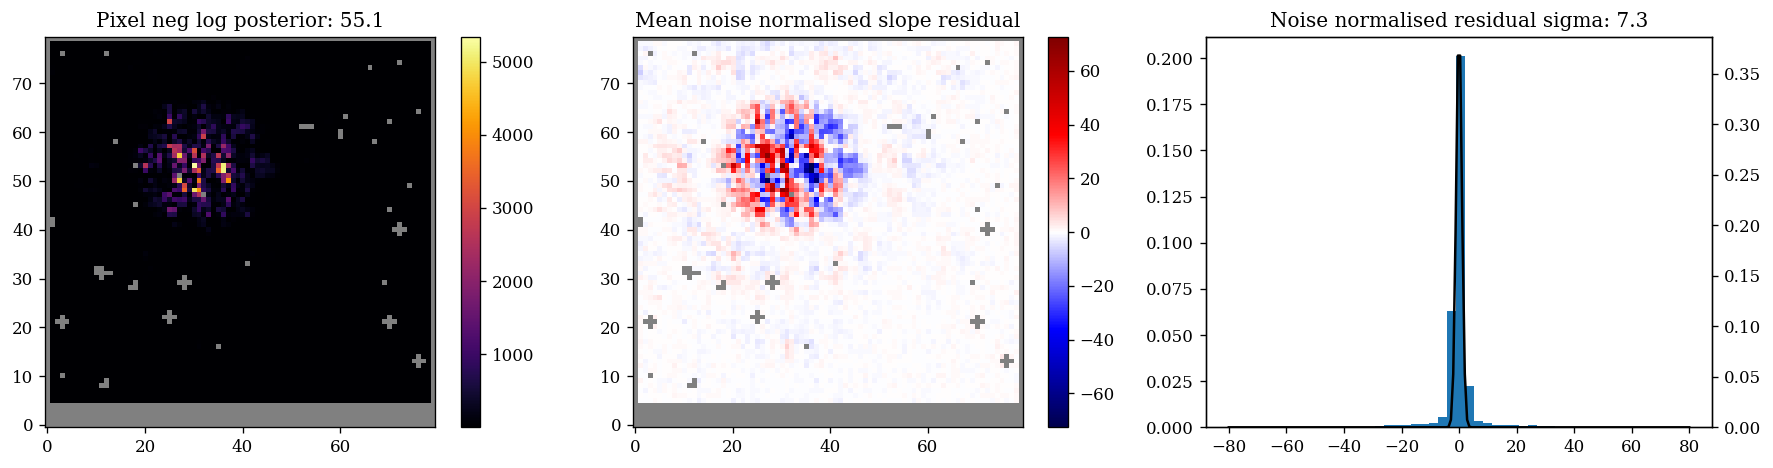

01093 F480M HD-36805 9 65


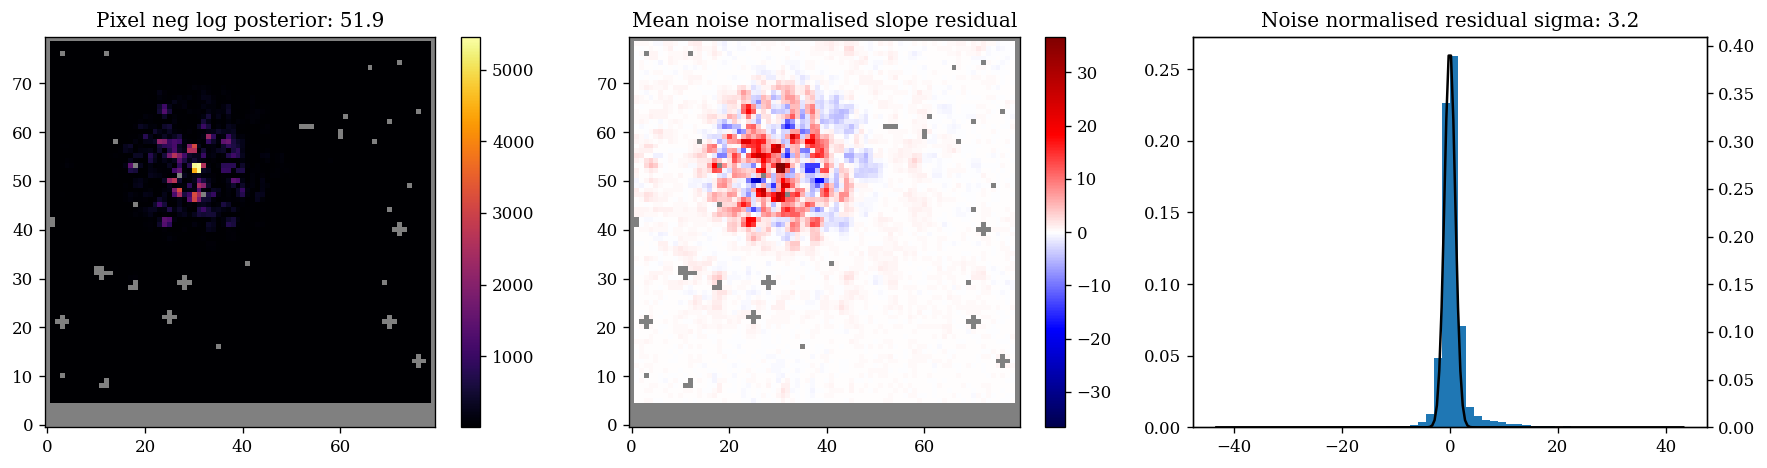

01093 F430M HD-36805 6 82


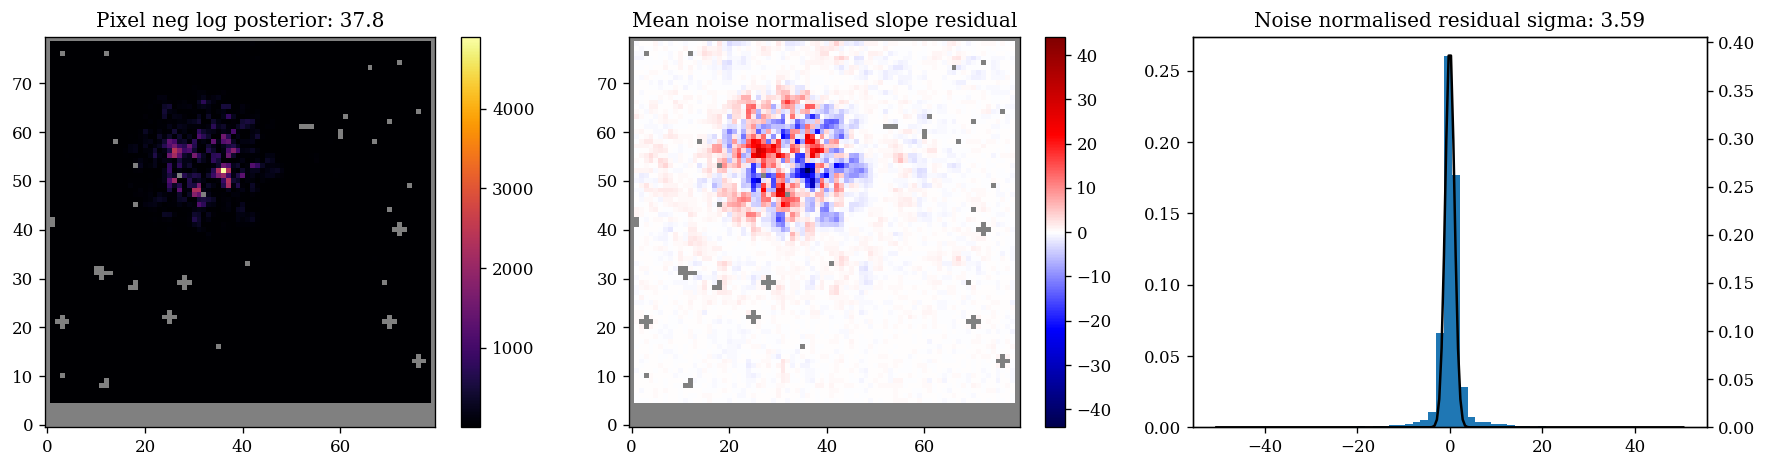

In [25]:
from amigo.plotting import summarise_fit


done = []
for exp in val_exposures:
    if exp.filter in done:
        continue
    print(exp.program, exp.filter, exp.star, exp.ngroups, exp.nints)
    summarise_fit(model, exp)
    done.append(exp.filter)

In [26]:
from amigo.misc import convert_adjacent_to_true

# for idx, (filt, _) in enumerate(exp_dict.items()):
n = 2
k = 2 * n + 1

# for exp in exp_dict[filt]:
for exp in flat_exposures[:1]:

    if exp.program != "FLAT":
        continue

    if int(exp.dither) != 1:
        continue

    print(exp.key)
    # summarise_fit(result.model, exp)

    # slopes = exp(result.model)
    slopes = exp(model)
    im = slopes.sum(0)
    peak_map = np.zeros_like(im).at[40, 40].set(1).astype(bool)
    peak_map = convert_adjacent_to_true(peak_map, corners=True, n=n)

    im_pred = np.where(exp.badpix, np.nan, slopes.sum(0))
    data = np.where(exp.badpix, np.nan, exp.slopes.sum(0))
    vmax = np.nanmax(np.abs(np.stack([im_pred, data])))
    vmin = np.nanmin(np.abs(np.stack([im_pred, data])))

    ind = np.where(peak_map)
    model_slopes = slopes[:, *ind].reshape(-1, k, k)
    data_slopes = exp.slopes[:, *ind].reshape(-1, k, k)
    data_std = exp.variance[:, *ind].reshape(-1, k, k) ** 0.5

    xs = np.arange(len(slopes))
    ymin, ymax = 0, np.nanmax(np.array([data_slopes, model_slopes]))

    # plt.figure(figsize=(4.1 * k, 4 * k))
    # # plt.suptitle(filt)

    # for i in range(k):
    #     for j in range(k):
    #         plt.subplot(k, k, i * k + j + 1)
    #         plt.title("Slopes")
    #         plt.xlabel("Slope Index")
    #         plt.ylabel("Slope (e- / group)")
    #         plt.errorbar(
    #             xs, data_slopes[:, i, j], yerr=data_std[:, i, j], marker='o', capsize=5, label="Data", c='k'
    #         )
    #         plt.errorbar(
    #             xs, model_slopes[:, i, j], marker='o', capsize=5, label="Model"
    #         )
    #         plt.legend()

    # plt.tight_layout()
    # plt.show()

flat_CLEAR_10


FLAT CLEAR NIS_LAMP 10 11


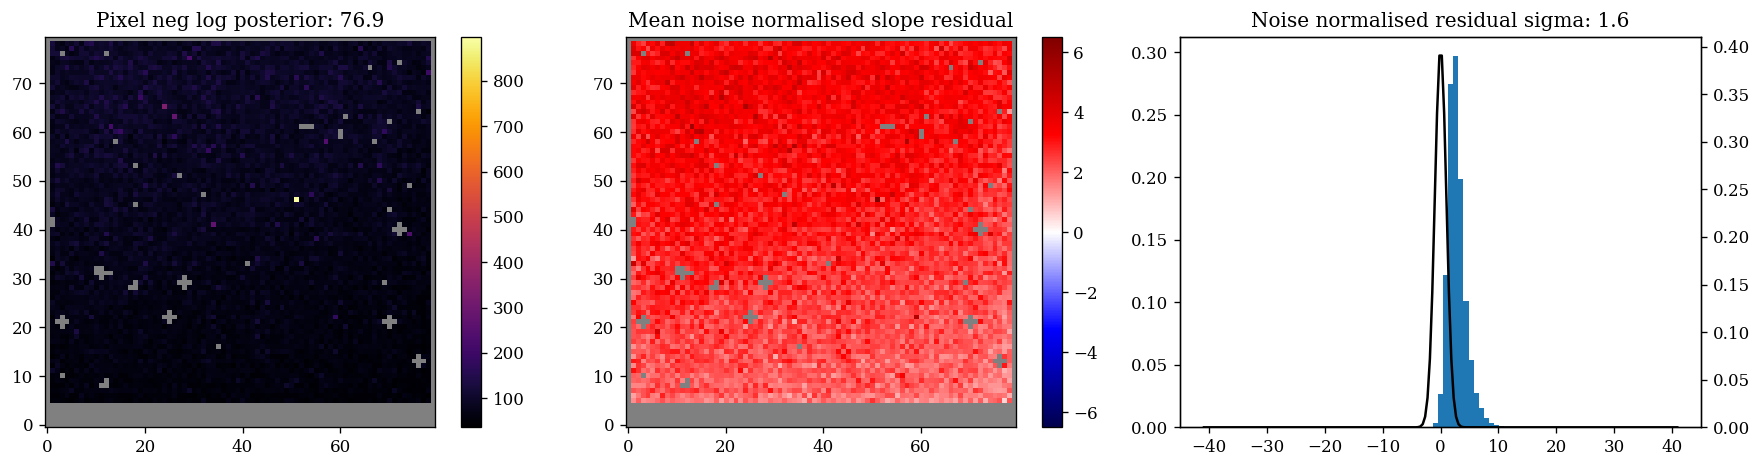

FLAT CLEAR NIS_LAMP 20 33


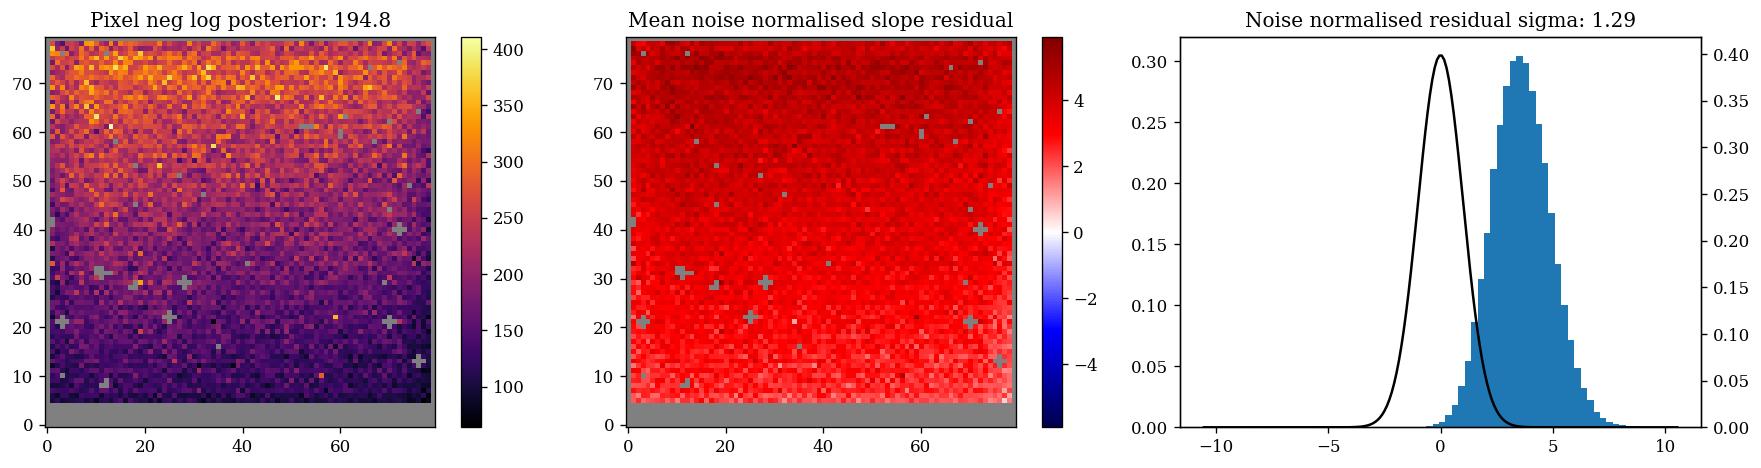

FLAT F277W NIS_LAMP 20 10


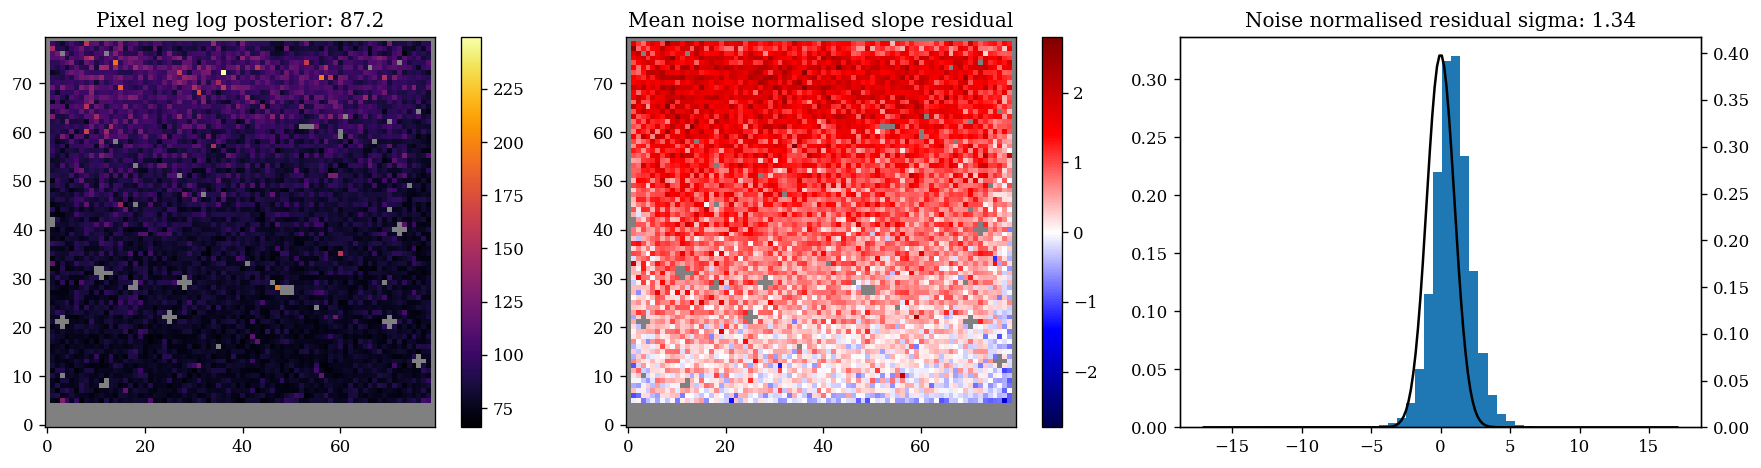

FLAT F356W NIS_LAMP 20 10


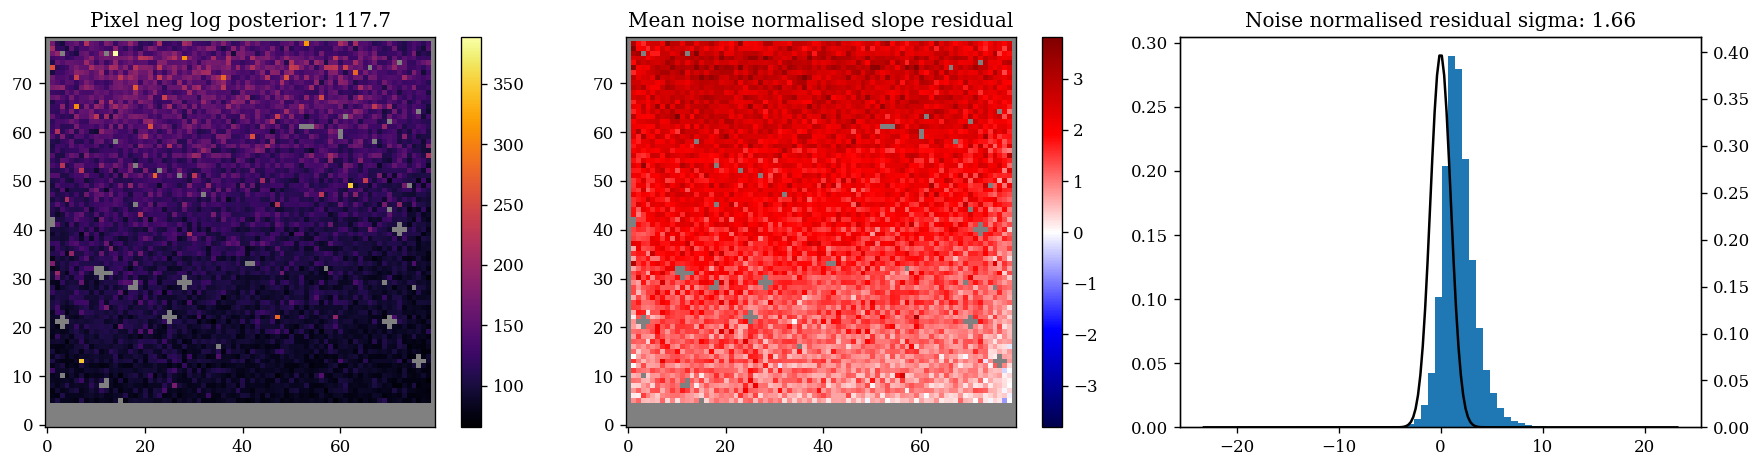

FLAT F444W NIS_LAMP 20 10


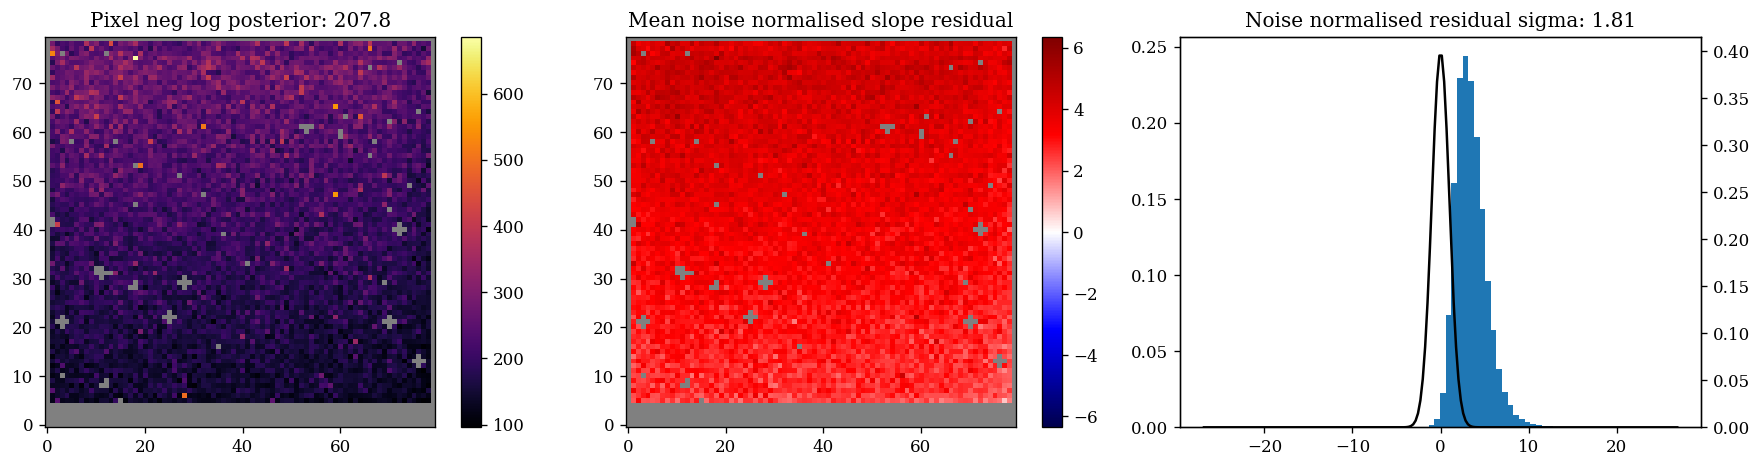

FLAT CLEAR NIS_LAMP 25 11


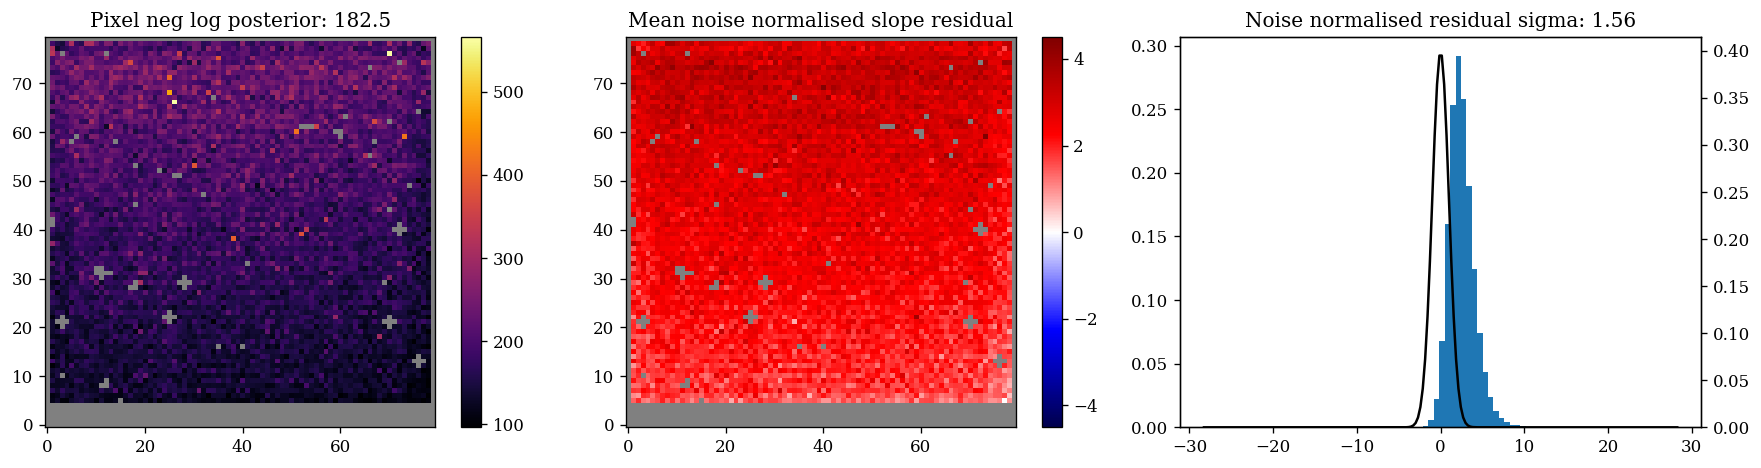

FLAT F380M NIS_LAMP 30 10


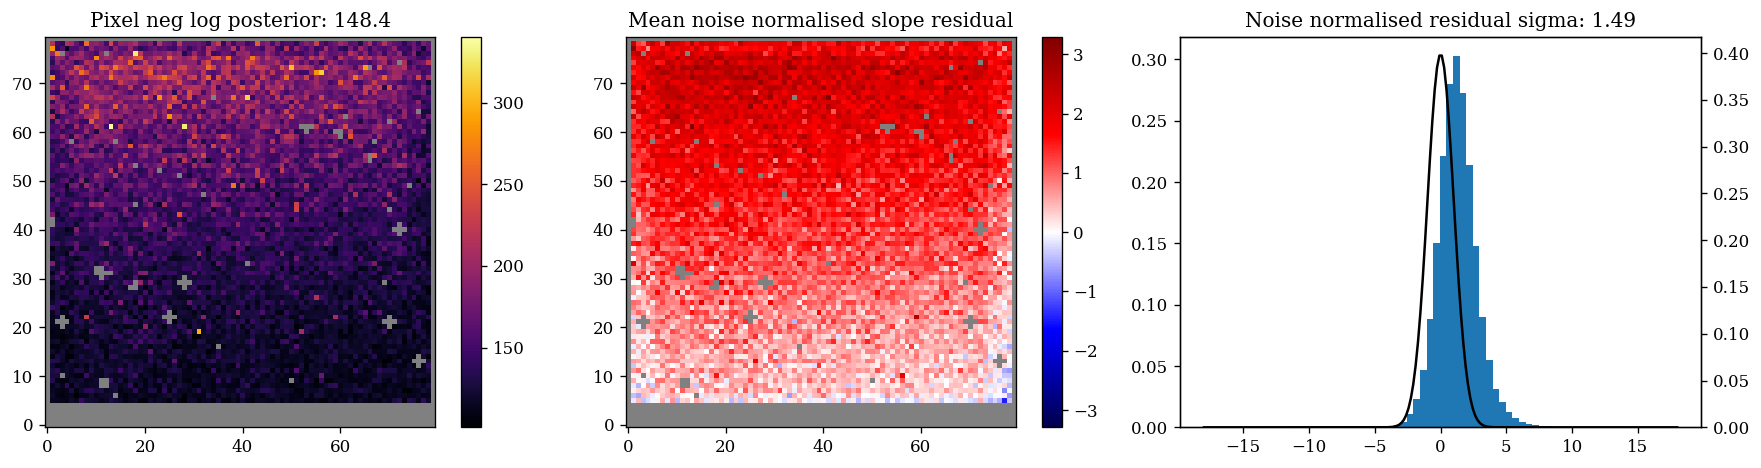

FLAT F430M NIS_LAMP 30 10


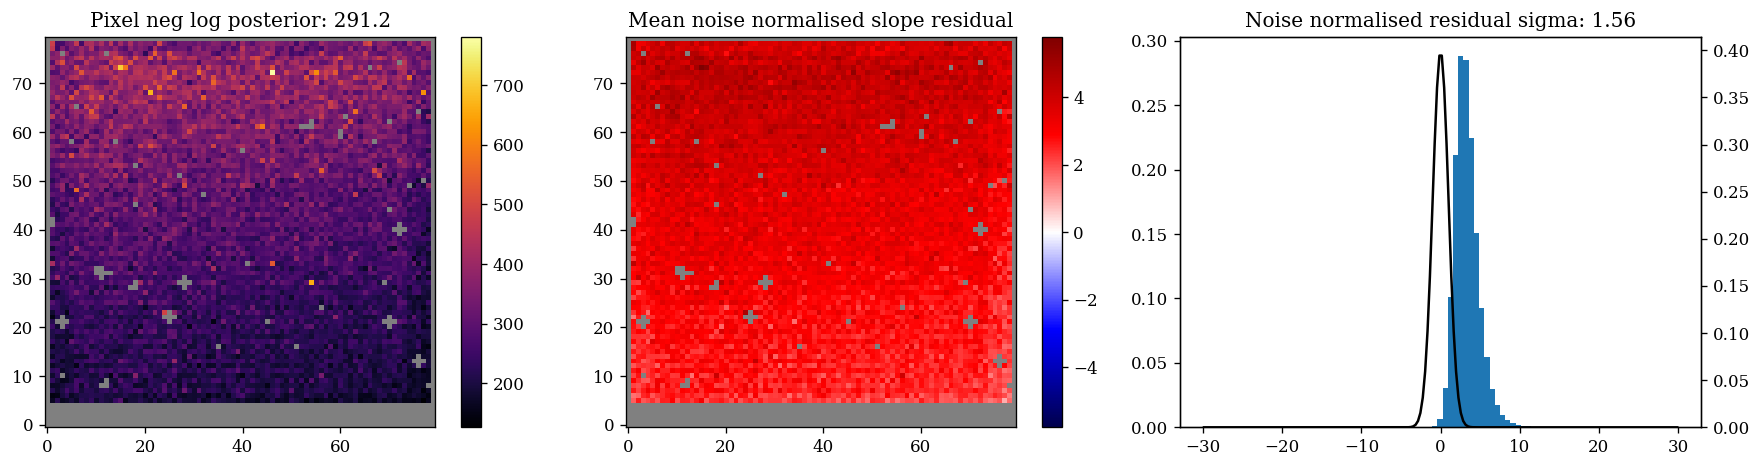

FLAT F480M NIS_LAMP 30 10


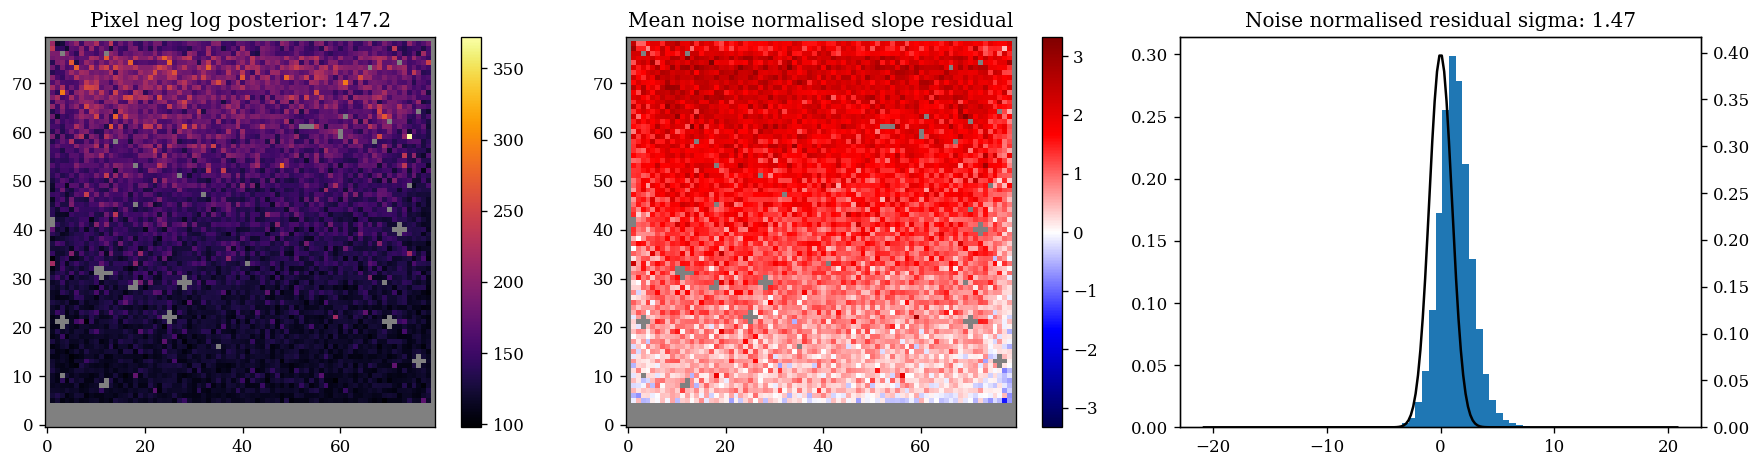

In [27]:
from amigo.plotting import summarise_fit


for exp in flat_exposures:
    slope_flux = exp.ngroups + (1 / exp.ngroups)
    cleaned_slopes = exp.slopes.sum(0)[~exp.badpix]
    flux = np.log10(model.gain * slope_flux * np.nansum(cleaned_slopes))

    # _model = model.set(exp.map_param("fluxes"), flux)
    # _model = result.model.set(exp.map_param("fluxes"), flux)

    print(exp.program, exp.filter, exp.star, exp.ngroups, exp.nints)
    # summarise_fit(_model, exp)
    summarise_fit(model, exp)

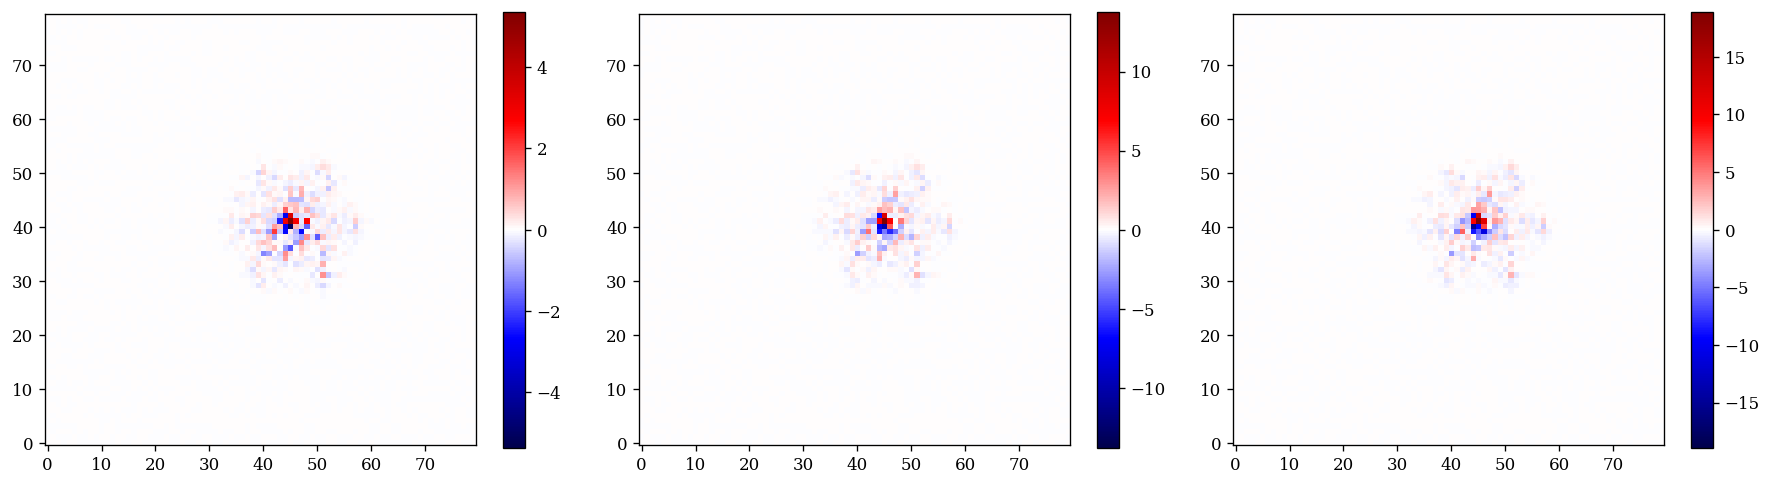

In [28]:
for exp in cal_exposures:
    if exp.filter == "F430M":
        break

_model = model.multiply("nn_weights", 1)
psf = exp.model_psf(_model)
illuminance = exp.model_illuminance(psf, _model)
ramp = exp.model_ramp(illuminance, _model).data
slopes = np.diff(ramp, axis=0)

first = slopes[0]
inds = np.linspace(0, exp.nslopes, 4, dtype=int)[1:]

plt.figure(figsize=(15, 4))
for i, ind in enumerate(inds):
    res = first - slopes[ind]
    v = np.nanmax(np.abs(res))
    plt.subplot(1, 3, i + 1)
    plt.imshow(res, seismic, vmin=-v, vmax=v, label=f"{ind}")
    plt.colorbar()
plt.tight_layout()

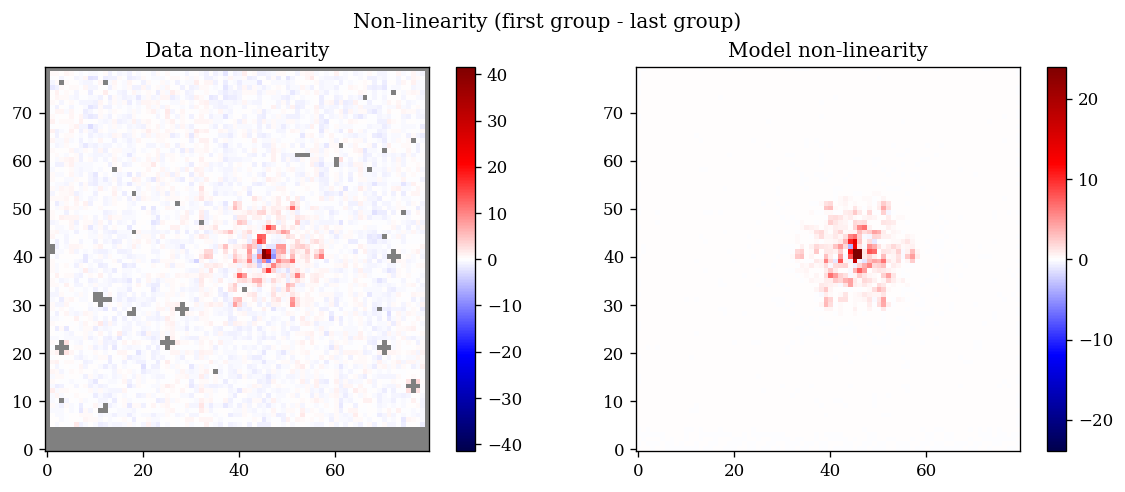

In [29]:
for exp in cal_exposures:
    if exp.filter == "F430M":
        break

first = np.where(exp.badpix, np.nan, exp.slopes[0])
last = np.where(exp.badpix, np.nan, exp.slopes[-1])

data_res = first - last
data_v = 0.25 * np.nanmax(np.abs(data_res))

slopes = exp(model.multiply("nn_weights", 1))
first, last = slopes[0], slopes[-1]
model_res = first - last
model_v = 0.25 * np.nanmax(np.abs(model_res))

plt.figure(figsize=(10, 4))
plt.suptitle("Non-linearity (first group - last group)")
plt.subplot(1, 2, 1)
plt.title("Data non-linearity")
plt.imshow(data_res, seismic, vmin=-data_v, vmax=data_v)
plt.colorbar()

plt.subplot(1, 2, 2)
plt.title("Model non-linearity")
plt.imshow(model_res, seismic, vmin=-model_v, vmax=model_v)
plt.colorbar()

plt.tight_layout()
plt.show()

In [30]:
import jax.numpy as np
import jax.random as jr
from jax import vmap

badpix = np.zeros((80, 80))
for exp in exposures:
    badpix += exp.badpix.astype(int)
badpix = badpix == len(exposures)


def norm_fn(model_params, args):

    if hasattr(model_params, "FF"):
        FF = model_params.FF
        FF -= np.median(FF) - 1.0
        FF = FF.at[badpix].set(1.0)
        model_params = model_params.set("FF", FF)

    if hasattr(model_params, "non_linearity"):
        non_lin = model_params.non_linearity.at[:, badpix].set(0)
        model_params = model_params.set("non_linearity", non_lin)

    return model_params, args


def posterior(model, exposure, l2_norm=0.0, ff_std=0.035, nl_std=0.025):

    # Loss
    z_score = exposure.mv_zscore(model)

    # L2 regularisation
    l2_reg = -l2_norm * np.mean(model.nn_weights**2)

    # FF prior
    ff_norm = model.FF - 1
    ff_reg = -np.mean((ff_norm / ff_std) ** 2)

    # Non linearity prior
    nl_norm = model.non_linearity - model.non_linearity.mean()
    nl_reg = -np.mean((nl_norm / nl_std) ** 2)

    prior = l2_reg + ff_reg + nl_reg

    return z_score + prior, (z_score, l2_reg, ff_reg, nl_reg)


def loss_fn(model, exposure, args={"l2": 0.0}):
    # loss, (z_score, l2_reg) = posterior(model, exposure, l2_norm=args["l2"])
    loss, args = posterior(model, exposure, l2_norm=args["l2"])
    return -np.nanmean(loss), (-np.nanmean(args[0]), *args[1:])


def args_fn(model, args, epoch):
    args["l2"] = args["l2_schedule"][epoch]
    return model, args


def cosine_warmup(t, t0, n_max):
    # Make the cosine curve
    x = (t - t0) * np.pi / n_max
    half_cos = 0.5 * (1 + (np.cos(x + np.pi)))

    # Set all values > n to 1.
    half_cos = np.where(t > n_max + t0, 1, half_cos)
    half_cos = np.where(t < t0, 0.0, half_cos)
    return half_cos


def temp_decay(T0, k, t):
    return T0 * np.exp(-k * t)


def get_warmup(args):
    return cosine_warmup(args["t"], args["t0"], args["n_max"])


def get_temperature(args):
    return temp_decay(args["T0"], args["k"], args["t"])


def grads_fn(model, grads, args):
    # Get the parameters
    grad_params = grads.params

    # Get the key and update args with new key
    key, subkey = jr.split(args["key"], 2)
    args["key"] = subkey

    # Adds a temperature to the NN gradients
    values = grad_params["nn_weights"]

    # Add the learning rate warm-up (we also warm up the temperature here)
    values *= args["max_lr"] * get_warmup(args)

    #
    rand_vals = get_temperature(args) * jr.normal(key, values.shape)
    values += rand_vals

    # Increment the t parameter
    args["t"] += 1.0 / args["n_batch"]

    # Update with the new values
    grad_params["nn_weights"] = values
    grads = grads.set("params", grad_params)
    return grads, args

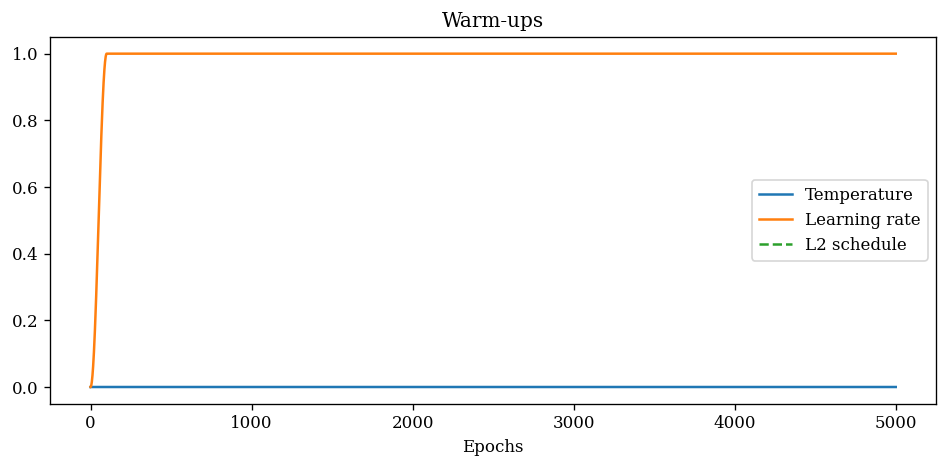

In [31]:
from amigo.fitting import batch_exposures

# Get the batches: Calibrator, flats, and validators
cal_batch = batch_exposures(cal_exposures, batch_size=3, key="cal")
flat_batch = batch_exposures(flat_exposures, batch_size=3, key="flat")
val_batch = batch_exposures(val_exposures, batch_size=3, key="val")
batches = {**cal_batch, **flat_batch}

#
# epochs = 1500
epochs = 5000
n_batch = len(batches)

# T0 = 1.
T0 = 1e-6
# decay = 0.03
# decay = 0.002
decay = 0.005

max_lr = 1.0
t0 = 0  # Warm-up start
# n_max = 250  # Warm-up end
n_max = 100  # Warm-up end

args = {
    "key": jr.key(0),  # RNG Key
    "t": np.array(0.0),  # Initial time step
    "n_batch": np.array(n_batch, float),  # Number of batches
    #
    "T0": np.array(T0),  # Initial temperature
    "k": np.array(decay),  # Decay rate
    # "l2": np.array(0.0),
    #
    "t0": np.array(t0),
    "n_max": np.array(n_max),  # Warm-up end point
    "max_lr": np.array(max_lr),  # Minimum warm-up learning rate
}

ts = np.arange(epochs)
temps = temp_decay(args["T0"], args["k"], ts)
lrs = cosine_warmup(ts, args["t0"], args["n_max"])
# l2s = 250 * cosine_warmup(ts, 0, 1000)
l2s = 0 * cosine_warmup(ts, 0, 1000)

args = {**args, **{"l2_schedule": l2s}}

plt.figure(figsize=(8, 4))
plt.title("Warm-ups")
plt.plot(ts, temps, label="Temperature")
plt.plot(ts, lrs, label="Learning rate")
plt.plot(ts, l2s / l2s.max(), "--", label="L2 schedule")
plt.xlabel("Epochs")
plt.legend()

plt.tight_layout()
plt.show()

In [32]:
# from amigo.calibration import ValBatchedTrainer, looper_fn, aux_fn

# trainer = ValBatchedTrainer(
#     loss_fn,
#     args_fn=args_fn,
#     looper_fn=looper_fn,
#     grad_fn=grads_fn,
#     norm_fn=norm_fn,
#     aux_fn=aux_fn,
#     cache="../../files",
# )

# trainer = trainer.update_fishers(
#     model,
#     cal_exposures,
#     recalculate=True,
#     save=True,
#     overwrite=True,
#     parameters=[
#         "SRF",
#     ],
# )

In [33]:
from amigo.calibration import ValBatchedTrainer, looper_fn, aux_fn

# NOTE: This seems to nuke the jitter/SRF gradient??
linear_model = model.set(["psf_upsample", "bleed"], [1, False])

trainer = ValBatchedTrainer(
    loss_fn,
    args_fn=args_fn,
    looper_fn=looper_fn,
    grad_fn=grads_fn,
    norm_fn=norm_fn,
    aux_fn=aux_fn,
    cache="../../files",
)

trainer = trainer.update_fishers(
    linear_model,
    flat_exposures,
    parameters=["flat_coeffs", "fluxes"],
)

trainer = trainer.update_fishers(
    linear_model,
    val_exposures,
    batch_size=20,
    parameters=["positions", "aberrations", "fluxes", "spectra"],
)


trainer = trainer.update_fishers(
    linear_model,
    cal_exposures,
    batch_size=20,
    parameters=["distortion", "defocus", "aberrations", "primary_beam"],
)


trainer = trainer.update_fishers(
    linear_model,
    cal_exposures,
    parameters=[
        "positions",
        "fluxes",
        "spectra",
        "jitter",
        "dark_current",
        "SRF",
    ],
)

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

In [34]:
from amigo.fitting import sgd, adam

# Define the optimisers
optimisers = {
    "nn_weights": adam(1e-3, 10),  # lr applied with warm up
    "positions": sgd(1e-1, 0),
    "fluxes": sgd(1e-1, 0),
    "flat_coeffs": sgd(2e-2, 0),
    "aberrations": sgd(2e-2, 5),
    "jitter": sgd(1e-2, 15),  # start at 50th?
    "defocus": sgd(2e-1, 25),
    "distortion": sgd(5e-2, 30),
    "dark_current": sgd(2e-2, 35),
    "primary_beam": sgd(1e-2, 40),
    "non_linearity": sgd(1e-4, 100),
    "FF": sgd(2e-4, 150),
    "SRF": sgd(2e-3, 250),
    "spectra": sgd(5e-2, 1000),
}


# This seems to fix some recompile issues
def fn(x):
    if isinstance(x, jax.Array):
        if "i" in x.dtype.str:
            return x
        return np.array(x, dtype=float)
    return x


model = jtu.map(fn, model)

# Train the model
result = trainer.train(
    model=model,
    optimisers=optimisers,
    epochs=epochs,
    batches=batches,
    validators=val_batch,
    batched_params=["nn_weights"],
    validator_params=["positions", "fluxes", "aberrations", "spectra"],
    args=args,
)

  0%|          | 0/5000 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...
Compiling Loss function...
Compiling Loss function...
Compiling Loss function...
Compiling Loss function...
Compiling Loss function...
Compiling Loss function...
Compiling Loss function...
Compiling Loss function...
Compiling Loss function...
Compiling Loss function...
Compiling update function...
Compile time: 0:03:18

Initial_loss Loss: 318.04


EquinoxRuntimeError: Above is the stack outside of JIT. Below is the stack inside of JIT:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/mc/miniconda3/envs/retrain/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/mc/miniconda3/envs/retrain/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/mc/miniconda3/envs/retrain/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 758, in start
    self.io_loop.start()
  File "/Users/mc/miniconda3/envs/retrain/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 211, in start
    self.asyncio_loop.run_forever()
  File "/Users/mc/miniconda3/envs/retrain/lib/python3.12/asyncio/base_events.py", line 645, in run_forever
    self._run_once()
  File "/Users/mc/miniconda3/envs/retrain/lib/python3.12/asyncio/base_events.py", li

In [ ]:
aux = jtu.map(lambda x: np.array(x), result.aux, is_leaf=lambda x: isinstance(x, list))

#
cal, val, flat = [], [], []
for (batch_key, exp_key), value in aux["loglike"].items():
    if "cal" in batch_key:
        cal.append(value)
    if "val" in batch_key:
        val.append(value)
    if "flat" in batch_key:
        flat.append(value)
cal = np.array(cal)
val = np.array(val)
flat = np.array(flat)

#
mean_val = np.array(val).mean(0)
best = mean_val.min()
idx = np.where(mean_val == mean_val.min())[0][0]
test_aux = jtu.map(
    lambda x: x[: idx + 1], result.aux, is_leaf=lambda x: isinstance(x, list)
)
print(f"Best: {idx}")
print(looper_fn(result.losses, test_aux))

#
l2_regs = []
for (batch_key, exp_key), value in aux["l2_reg"].items():
    l2_regs.append(value)
l2_regs = np.array(l2_regs).mean(0)

print(looper_fn(result.losses, result.aux))

In [ ]:
#
mean_val = np.array(val).mean(0)
best = mean_val.min()
idx = np.where(mean_val == mean_val.min())[0][0]
print(idx)

#
final_state = result.state
best_params = result.best_state.params
best_ramp_values = np.array(result.best_batch["nn_weights"]).mean(0)
best_params["nn_weights"] = best_ramp_values
best_state = result.best_state.set("params", best_params)
result = result.set("model", best_state.inject(model))

np.save("new_best_state.npy", best_params, allow_pickle=True)
np.save("new_final_state.npy", result.state.params, allow_pickle=True)

In [ ]:
# result.state

In [ ]:
# best_params.keys()

In [ ]:
# _state = np.load("new_final_state.npy", allow_pickle=True).item()

In [ ]:
# np.save("new_final_state.npy", best_params, allow_pickle=True)

In [ ]:
# np.save("new_best_state.npy", result.state, allow_pickle=True)

# _state = np.load("new_best_state.npy", allow_pickle=True).item()

In [ ]:
# Get the aberrations per filter
aberrations = {
    key.split("_")[1]: val
    for key, val in result.best_state.aberrations.items()
    if "04481" in key
}

# Get the best aperture mask
optics = result.model.optics
mask = optics.pupil_mask.calc_mask(optics.wf_npixels, optics.diameter)

#
cal_params = {
    "FF": result.best_state["FF"],
    "non_linearity": result.best_state["non_linearity"],
    "jitter": result.best_state["jitter"],
    "dark_current": result.best_state["dark_current"],
    "defocus": result.best_state["defocus"],
    "aberrations": aberrations,
    "nn_weights": best_ramp_values,
    "transmission": mask,
}

# np.save("../../GPU_files/results/cal_model", cal_params, allow_pickle=True)

# TODO: Evaluate the Visibility model projection matrices and save

In [ ]:
#
# epochs = cal.shape[-1]
# start, stop = 500, -1
start, stop = 50, -1


if stop < 0:
    stop = cal.shape[-1] + stop
xs = np.arange(start, stop)

print(np.array(cal).mean(0)[xs].shape)

plt.figure(figsize=(18, 4))
ax = plt.subplot(1, 3, 1)
plt.plot(xs, np.array(cal).mean(0)[xs])
ax.set(title="Calibrators", xlabel="Epochs", ylabel="Loss")

ax = plt.subplot(1, 3, 2)
ax.set(title="Validators", xlabel="Epochs", ylabel="Loss")
plt.plot(xs, np.array(val).mean(0)[xs])

ax = plt.subplot(1, 3, 3)
ax.set(title="Flat", xlabel="Epochs", ylabel="Loss")
plt.plot(xs, np.array(flat).mean(0)[xs])

plt.tight_layout()
plt.show()

###

plt.figure(figsize=(18, 4))
ax = plt.subplot(1, 3, 1)
ax.set(title="Calibrators", xlabel="Epochs", ylabel="Loss")
[plt.plot(xs, ys[xs]) for ys in cal]

ax = plt.subplot(1, 3, 2)
ax.set(title="Validators", xlabel="Epochs", ylabel="Loss")
[plt.plot(xs, ys[xs]) for ys in val]

ax = plt.subplot(1, 3, 3)
ax.set(title="Flat", xlabel="Epochs", ylabel="Loss")
[plt.plot(xs, ys[xs]) for ys in flat]

plt.tight_layout()
plt.show()

###

plt.figure(figsize=(8, 3))
ax = plt.subplot(1, 1, 1)
ax.set(title="L2 Regularisation", xlabel="Epochs", ylabel="Loss")
plt.plot(xs, l2_regs[xs])
plt.tight_layout()
plt.show()

In [ ]:
#
# epochs = cal.shape[-1]
start, stop = 1000, -1


if stop < 0:
    stop = cal.shape[-1] + stop
xs = np.arange(start, stop)

print(np.array(cal).mean(0)[xs].shape)

plt.figure(figsize=(18, 4))
ax = plt.subplot(1, 3, 1)
plt.plot(xs, np.array(cal).mean(0)[xs])
ax.set(title="Calibrators", xlabel="Epochs", ylabel="Loss")

ax = plt.subplot(1, 3, 2)
ax.set(title="Validators", xlabel="Epochs", ylabel="Loss")
plt.plot(xs, np.array(val).mean(0)[xs])

ax = plt.subplot(1, 3, 3)
ax.set(title="Flat", xlabel="Epochs", ylabel="Loss")
plt.plot(xs, np.array(flat).mean(0)[xs])

plt.tight_layout()
plt.show()

###

plt.figure(figsize=(18, 4))
ax = plt.subplot(1, 3, 1)
ax.set(title="Calibrators", xlabel="Epochs", ylabel="Loss")
[plt.plot(xs, ys[xs]) for ys in cal]

ax = plt.subplot(1, 3, 2)
ax.set(title="Validators", xlabel="Epochs", ylabel="Loss")
[plt.plot(xs, ys[xs]) for ys in val]

ax = plt.subplot(1, 3, 3)
ax.set(title="Flat", xlabel="Epochs", ylabel="Loss")
[plt.plot(xs, ys[xs]) for ys in flat]

plt.tight_layout()
plt.show()

###

plt.figure(figsize=(8, 3))
ax = plt.subplot(1, 1, 1)
ax.set(title="L2 Regularisation", xlabel="Epochs", ylabel="Loss")
plt.plot(xs, l2_regs[xs])
plt.tight_layout()
plt.show()

In [ ]:
import dLux.utils as dlu

filters = ["F380M", "F430M", "F480M"]
cols = ["tab:blue", "tab:orange", "tab:green"]

for i in range(4):
    start = int(dlu.triangular_number(i))
    end = int(dlu.triangular_number(i + 1))

    if i % 2 == 0:
        plt.figure(figsize=(12, 3))
        plt.subplot(1, 2, 1)
    else:
        plt.subplot(1, 2, 2)

    plt.title(f"Radial order: {i+1}")
    for filt, col in zip(filters, cols):
        abb_hist = np.array(result.history.aberrations[f"04481_{filt}"])
        plt.plot(
            abb_hist[:, :, start:end].reshape(-1, 7 * (end - start)), c=col, alpha=0.5
        )
        plt.plot([], c=col, label=filt)
    plt.legend()

    if i % 2 == 1:
        plt.tight_layout()
        plt.show()
plt.tight_layout()
plt.show()

In [ ]:
from amigo.plotting import plot

plot(result.history, ignore=["nn_weights", "FF", "non_linearity"])

In [ ]:
keep = ["FF", "non_linearity"]
ignore = [p for p in list(result.history.keys()) if p not in keep]

# plot(result.history, ignore=ignore)

In [ ]:
keep = ["nn_weights"]
ignore = [p for p in list(result.history.keys()) if p not in keep]

# plot(result.history, ignore=ignore, end=1000)

In [ ]:
encoder = result.model.kernel_model.bleed_encoder.build

for k, layer in enumerate(encoder.layers):
    print(k)
    print()
    print()

    if hasattr(layer, "weight"):
        kerns = layer.weight.reshape(-1, 3, 3)
        n = len(kerns)
        n_row = n // 8

        for i in range(n):
            if i % 8 == 0:
                plt.figure(figsize=(40, 4))

            plt.subplot(1, 8, i % 8 + 1)
            v = np.nanmax(np.abs(kerns[i]))
            plt.imshow(kerns[i], seismic, vmin=-3, vmax=3)
            plt.colorbar()

            if i % 8 == 7 or i == n - 1:
                plt.suptitle(f"{i // n_row + 1} of {n_row}")
                plt.tight_layout()
                plt.show()

            break
        break
    break

In [ ]:
# test_weights = np.where(np.abs(result.model.nn_weights) > 3, 0., result.model.nn_weights)

# test_model = result.model.set("nn_weights", test_weights)

In [ ]:
from amigo.plotting import summarise_fit

for filt in ["F380M", "F430M", "F480M"]:
    for batch_key, batch in cal_batch.items():
        for exp in batch:
            if exp.filter == filt:
                print("Calibrator", exp.filter, exp.dither)
                summarise_fit(result.model, exp)

In [ ]:
programs = list(set([exp.program for exp in val_exposures]))

for program in programs:
    for filt in ["F380M", "F430M", "F480M"]:
        # for exp in val_exposures:
        for batch_key, batch in val_batch.items():
            for exp in batch:
                if exp.filter == filt and exp.program == program:
                    flux = 10 ** result.model.get(exp.map_param("fluxes"))
                    phot = exp.nints * exp.ngroups * flux / 1e6
                    print(program, filt, exp.ngroups, f"{phot:.2f}")
                    summarise_fit(result.model, exp)

In [ ]:
import matplotlib.colors as mcolors

bp = np.load("../../amigo/src/amigo/data/badpix.npy")

badpix = np.zeros((80, 80))
for exp in flat_exposures:
    badpix += exp.badpix.astype(int)
badpix = ~(badpix == 0)

full_badpix = badpix | bp

badpix = badpix.astype(int)
bp = bp.astype(int)


plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.imshow(badpix)
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(bp)
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(full_badpix)
plt.colorbar()

plt.tight_layout()
plt.show()

# # np.save("../../GPU_files/badpix.npy", full_badpix)

In [ ]:
# for filt in ["F380M", "F430M", "F480M"]:
for batch_key, batch in flat_batch.items():
    for exp in batch:
        # badpix = exp.badpix
        # badpix = badpix.at[29, 69].set(True)
        # badpix = badpix.at[49, 74].set(True)
        # badpix = badpix.at[61, 52].set(True)
        # badpix = badpix.at[53, 18].set(True)
        # exp.set("support", np.where(~badpix))

        # badpix = exp.badpix.at[49, 74].set(True)

        # supp = np.where(~badpix)
        print("Flat", exp.filter, exp.dither, exp.nints, exp.ngroups)
        # summarise_fit(result.model, exp.set("support", np.where(~badpix)))
        summarise_fit(result.model, exp)

In [ ]:
result.model.non_linearity.shape

In [ ]:
import matplotlib.colors as mcolors

badpix = np.zeros((80, 80))
for exp in flat_exposures:
    badpix += exp.badpix.astype(int)
badpix = ~(badpix == 0)


FF = result.model.FF.at[badpix].set(np.nan)
non_lin = result.model.non_linearity[0].at[badpix].set(np.nan)

ff_xs = np.linspace(np.nanmin(FF), np.nanmax(FF), 100) - 1
ff_l2 = np.exp(-((ff_xs / 0.035) ** 2))

med_nl = np.nanmedian(non_lin)
nl_xs = np.linspace(np.nanmin(non_lin), np.nanmax(non_lin), 100)
nl_l2 = np.exp(-(((nl_xs - med_nl) / 0.025) ** 2))


one_norm = mcolors.CenteredNorm(vcenter=1)
zero_norm = mcolors.CenteredNorm(vcenter=0)
plt.figure(figsize=(10, 8))
plt.suptitle("Pixel Sensitivity and Non-Linearity")

plt.subplot(2, 2, 1)
plt.title("FF")
plt.imshow(FF, seismic, norm=one_norm)
plt.colorbar()

plt.subplot(2, 2, 2)
plt.title("Linear")
plt.imshow(non_lin, seismic)
plt.colorbar()

plt.subplot(2, 2, 3)
plt.title("FF")
plt.hist(FF[::2].flatten(), bins=100, density=True)
plt.hist(FF[1::2].flatten(), bins=100, alpha=0.75, density=True)
plt.plot(ff_xs + 1, 25 * ff_l2, label="L2", c="k")

plt.subplot(2, 2, 4)
plt.title("Linear")
plt.hist(non_lin[::2].flatten(), bins=100)
plt.hist(non_lin[1::2].flatten(), bins=100, alpha=0.75)
plt.plot(nl_xs, 150 * nl_l2, label="L2", c="k")


plt.tight_layout()
plt.show()

In [ ]:
stars = list(set([exp.star for exp in cal_exposures]))
stars += list(set([exp.star for exp in val_exposures]))

for targ_star in stars:
    plt.figure(figsize=(10, 4))
    for key, spec in result.model.spectra.items():
        star, filt = key.split("_")

        if star != targ_star:
            continue

        wavels, filt_weights = model.filters[filt]
        xs = np.linspace(-1, 1, len(wavels), endpoint=True)
        spectra_slopes = 1 + spec * xs
        weights = filt_weights * spectra_slopes  # * wavels

        #
        filt_weights = filt_weights / filt_weights.sum()
        spectra_slopes = spectra_slopes / spectra_slopes.sum()
        weights = weights / weights.sum()

        plt.plot(wavels, weights, label="Filter Weights")
        plt.plot(wavels, spectra_slopes, label="Spectral Weights")
        plt.plot(wavels, filt_weights, label="Combined Weights")

    plt.legend()
    plt.show()

In [ ]:
cal_aberrations = {
    key: val for key, val in result.state.aberrations.items() if "04481" in key
}
# cal_beam_coeffs = {key: val for key, val in result.state.beam_coeffs.items()}
# cal_aberrations = {key: val for key, val in model.aberrations.items() if "04481" in key}

optics = result.model.optics
pupil_mask = result.model.optics.pupil_mask

plt.figure(figsize=(15, 8))
plt.suptitle("Mirror Aberrations")
for i, key in enumerate(cal_aberrations):
    # coeffs = cal_beam_coeffs[key.split("_")[-1]]
    # pupil_mask = pupil_mask.set("primary_beam", coeffs)

    coeffs = result.model.aberrations[key]
    full_abb = pupil_mask.set("abb_coeffs", coeffs).calc_aberrations()
    flat_abb = pupil_mask.set("abb_coeffs", coeffs.at[:, :3].set(0)).calc_aberrations()

    mask = pupil_mask.calc_mask(optics.wf_npixels, optics.diameter)

    full_abb = np.where(mask < 1.0, np.nan, 1e9 * full_abb)
    flat_abb = np.where(mask < 1.0, np.nan, 1e9 * flat_abb)

    full_abb -= np.nanmean(full_abb)
    flat_abb -= np.nanmean(flat_abb)

    rms = lambda x: np.sqrt(np.nanmean(np.square(x)))

    # filt = key.split("_")[-1]

    v = np.nanmax(np.abs(full_abb))
    plt.subplot(2, 3, i + 1)
    plt.title(f"OPD {rms(full_abb):.2f} (nm)")
    plt.imshow(full_abb, cmap=seismic, vmin=-v, vmax=v)
    plt.colorbar(label="OPD (nm)")

    v = np.nanmax(np.abs(flat_abb))
    plt.subplot(2, 3, i + 4)
    plt.title(f"RMS OPD: {rms(flat_abb):.2f} nm")
    plt.imshow(flat_abb, cmap=seismic, vmin=-v, vmax=v)
    plt.colorbar(label="OPD (nm)")

plt.tight_layout()
plt.show()

In [ ]:
# null_pupil_mask = model.optics.pupil_mask.set("softness", np.array(1.0))
null_pupil_mask = model.optics.pupil_mask.multiply("primary_beam", 0.0)
null_pupil_mask = null_pupil_mask.multiply("distortion", 0.0)
null_mask = null_pupil_mask.calc_mask(optics.wf_npixels, optics.diameter)

pupil_mask = result.model.optics.pupil_mask
mask = pupil_mask.calc_mask(optics.wf_npixels, optics.diameter)
res = mask - null_mask

plt.figure(figsize=(5, 4))
plt.suptitle("Mask & Beam Distortions")
v = np.nanmax(np.abs(res))
# plt.subplot(1, 3, i + 1)
plt.title(filt)
plt.imshow(res, cmap=seismic, vmin=-v, vmax=v)

plt.tight_layout()
plt.show()

In [ ]:
from amigo.stats import variance_model

for filt in ["F380M", "F430M", "F480M"]:
    for exp in cal_exposures:
        if exp.filter == filt:
            break
    # exp = exposures[-1]
    abb_key = f"aberrations.{exp.get_key('aberrations')}"
    # defoc_key = f"defocus"

    slopes, var = variance_model(result.model, exp)
    final_psf, err = slopes.sum(0), np.sqrt(var.sum(0))

    def plot_effect(fig, ax, clean_psf, effect):
        res = clean_psf - final_psf
        rms = np.sqrt(np.mean(np.square(res)))
        v = v_ceil * np.nanmax(np.abs(res))
        im = ax.imshow(res, seismic, vmin=-v, vmax=v)
        fig.colorbar(im, cax=merge_cbar(ax), label="Counts")
        ax.set(
            title=f"{effect}: {rms:.2f} rms counts", xlabel="Pixels", ylabel="Pixels"
        )

    # for v_ceil in [1, 0.25]:
    for v_ceil in [0.25]:
        fig = plt.figure(figsize=(15, 4))
        plt.suptitle("Calibration model effects")

        ax = plt.subplot(1, 3, 1)
        optical_model = result.model.multiply(
            # [abb_key, defoc_key, "distortion"], 0
            [abb_key, "distortion"],
            0,
        ).set(["jitter", "f2f"], [1e-16, 0.8])
        optical_psf = exp(optical_model).sum(0)
        plot_effect(fig, ax, optical_psf, "Optical PSF")

        ax = plt.subplot(1, 3, 2)
        resample_model = result.model.multiply("rotation", 0.0).set("anisotropy", 1.0)
        resample_psf = exp(resample_model).sum(0)
        plot_effect(fig, ax, resample_psf, "Resampling")

        ax = plt.subplot(1, 3, 3)
        non_lin_psf = exp(result.model.multiply("nn_weights", 0.0)).sum(0)
        plot_effect(fig, ax, non_lin_psf, "Non-Linearity")

        plt.tight_layout()
        plt.show()

In [ ]:
from amigo.stats import variance_model

for filt in ["F380M", "F430M", "F480M"]:
    for exp in cal_exposures:
        if exp.filter == filt:
            break
    # exp = exposures[-1]
    # abb_key = f"aberrations.{exp.get_key('aberrations')}"
    # abb_key = exp.map_param("aberrations")
    # phase_key = exp.map_param("phases")
    # print(phase_key)
    # defoc_key = f"defocus"

    # slopes, var = variance_model(result.model, exp)
    flux = 10 ** result.model.get(exp.map_param("fluxes"))
    final_psf = flux * exp.model_psf(result.model).data
    err = np.sqrt(final_psf)
    # final_psf, err = slopes.sum(0), np.sqrt(var.sum(0))

    def plot_effect(fig, ax, clean_psf, effect):
        res = clean_psf - final_psf  # / err
        rms = np.sqrt(np.mean(np.square(res)))
        v = v_ceil * np.nanmax(np.abs(res))
        im = ax.imshow(res, seismic, vmin=-v, vmax=v)
        fig.colorbar(im, cax=merge_cbar(ax), label="Counts")
        ax.set(
            title=f"{effect}: {rms:.2f} rms counts", xlabel="Pixels", ylabel="Pixels"
        )

    # for v_ceil in [1, 0.25]:
    for v_ceil in [1]:
        fig = plt.figure(figsize=(15, 8))
        plt.suptitle(f"Optical Effects: {filt}")

        abb_key = exp.map_param("aberrations")

        ax = plt.subplot(2, 3, 1)
        optical_model = result.model.multiply(abb_key, 0)
        optical_psf = flux * exp.model_psf(optical_model).data
        plot_effect(fig, ax, optical_psf, "Aberrations")

        ax = plt.subplot(2, 3, 2)
        abb = result.model.get(abb_key).at[:, 3:].set(0.0)
        optical_model = result.model.set(abb_key, abb)
        optical_psf = flux * exp.model_psf(optical_model).data
        plot_effect(fig, ax, optical_psf, "Flat Aberrations")

        ax = plt.subplot(2, 3, 3)
        optical_model = result.model.set(exp.map_param("defocus"), 0.0)
        optical_psf = flux * exp.model_psf(optical_model).data
        plot_effect(fig, ax, optical_psf, "Defocus")

        ax = plt.subplot(2, 3, 4)
        optical_model = result.model.multiply(["primary_beam", "distortion"], 0)
        optical_psf = flux * exp.model_psf(optical_model).data
        plot_effect(fig, ax, optical_psf, "Aperture Distortions")

        ax = plt.subplot(2, 3, 5)
        # optical_model = result.model.multiply("distortion", 0)
        # optical_psf = flux * exp.model_psf(optical_model).data
        # plot_effect(fig, ax, optical_psf, "Mask Distortion")

        ax = plt.subplot(2, 3, 6)
        optical_model = result.model.set(exp.map_param("spectra"), 0.0)
        optical_psf = flux * exp.model_psf(optical_model).data
        plot_effect(fig, ax, optical_psf, "Spectral slope")

        plt.tight_layout()
        plt.show()

In [ ]:
for exp in cal_exposures:
    if exp.filter == "F430M":
        break

psf = exp.model_psf(result.model)
illuminance = exp.model_illuminance(psf, result.model)
ramp = exp.model_ramp(illuminance, result.model).data
slopes = np.diff(ramp, axis=0)

first = slopes[0]
inds = np.linspace(0, exp.nslopes, 4, dtype=int)[1:]

plt.figure(figsize=(15, 4))
for i, ind in enumerate(inds):
    res = first - slopes[ind]
    v = 0.5 * np.nanmax(np.abs(res))
    plt.subplot(1, 3, i + 1)
    plt.imshow(res, seismic, vmin=-v, vmax=v, label=f"{ind}")
    plt.colorbar()
plt.tight_layout()
plt.show()

first_res = first - slopes[1]
last_res = first - slopes[-1]
res = first_res - last_res
v = np.nanmax(np.abs(res))
plt.imshow(res, seismic, vmin=-v, vmax=v)
plt.colorbar()
plt.show()

In [ ]:
print(exp.filter)

for exp in exposures:
    if exp.filter == "F430M":

        break

first = np.where(exp.badpix, np.nan, exp.slopes[0])
last = np.where(exp.badpix, np.nan, exp.slopes[-1])

data_res = first - last
data_v = 0.25 * np.nanmax(np.abs(data_res))


slopes = exp(result.model)
first, last = slopes[0], slopes[-1]
model_res = first - last
model_v = 0.25 * np.nanmax(np.abs(model_res))

plt.figure(figsize=(10, 4))
plt.suptitle("Non-linearity (first group - last group)")
plt.subplot(1, 2, 1)
plt.title("Data non-linearity")
plt.imshow(data_res, seismic, vmin=-data_v, vmax=data_v)
plt.colorbar()

plt.subplot(1, 2, 2)
plt.title("Model non-linearity")
plt.imshow(model_res, seismic, vmin=-model_v, vmax=model_v)
plt.colorbar()

plt.tight_layout()
plt.show()

In [ ]:
import dLux.utils as dlu
from amigo.ramp_models import quadratic_SRF

# Subpixel response
srf_map = quadratic_SRF(result.model.SRF, 3)
srf_map -= srf_map.max() - 1

# Jitter kernel
pscale = result.model.psf_pixel_scale / 3
kern = result.model.jitter_model.generate_kernel(pscale)
r = 1e3 * (len(kern) * pscale) / 4
print(result.model.jitter)

# Plot
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.title("Subpixel Response Function")
plt.imshow(srf_map, extent=(-0.5, 0.5, -0.5, 0.5))
plt.colorbar()
plt.xlabel("x (pixel)")
plt.ylabel("y (pixel)")

plt.subplot(1, 2, 2)
plt.title("Jitter Kernel")
plt.imshow(kern, extent=(-r, r, -r, r))
plt.colorbar()
plt.xlabel("x (mas)")
plt.ylabel("y (mas)")

plt.tight_layout()
plt.show()

In [ ]:
srf_map = quadratic_SRF(result.model.SRF, 3)

srf_map

In [ ]:
from scripts.stats import posterior

# Create the exposure dictionary
exp_dict = {}
for exp in exposures:
    if exp.filter not in exp_dict:
        exp_dict[exp.filter] = []
    exp_dict[exp.filter].append(exp)

#
for filt in ["F380M", "F430M", "F480M"]:
    fig = plt.figure(figsize=(25, 5))
    plt.suptitle(filt)
    for i in range(5):
        for exp in exp_dict[filt]:
            if int(exp.dither) == (i + 1):
                break
        # posterior_vec, aux = posterior(result.model, exp)
        # posterior_vec = exp.loglike(result.model)
        posterior_vec = exp.mv_zscore(result.model)

        posterior_im = exp.from_vec(-posterior_vec)

        ax = plt.subplot(1, 5, i + 1)
        im = plt.imshow(posterior_im, inferno)
        fig.colorbar(im, cax=merge_cbar(ax))
        ax.set(title=f"dither {exp.dither}: {-posterior_vec.mean():.2f}")

    plt.tight_layout()
    plt.show()

In [ ]:
for filt in ["F380M", "F430M", "F480M"]:

    fig = plt.figure(figsize=(25, 5))
    plt.suptitle(filt)

    for i in range(5):
        for exp in exp_dict[filt]:
            if int(exp.dither) == (i + 1):
                break

        slopes = exp(result.model)  # .model(exp)
        residual = exp.slopes - slopes
        norm_res_slope = residual / (exp.variance**0.5)
        norm_res_slope = norm_res_slope.at[:, exp.badpix].set(np.nan)

        ax = plt.subplot(1, 5, i + 1)
        v = np.nanmax(np.abs(norm_res_slope.mean(0)))
        im = plt.imshow(norm_res_slope.mean(0), vmin=-v, vmax=v, cmap=seismic)
        fig.colorbar(im, cax=merge_cbar(ax))
        ax.set(title=f"dither {exp.dither}")

    plt.tight_layout()
    plt.show()

In [ ]:
plt.hist(model.nn_weights, bins=100)
plt.hist(result.model.nn_weights, bins=100, alpha=0.5)
plt.show()

In [ ]:
kernel_model = result.model.ramp_model.kernel_model
init_layers = model.ramp_model.kernel_model.bleed_encoder.build.layers


for i, layer in enumerate(kernel_model.bleed_encoder.build.layers):
    if hasattr(layer, "weight"):
        plt.hist(init_layers[i].weight.flatten(), bins=100)
        plt.hist(layer.weight.flatten(), bins=100, alpha=0.5)
        plt.show()

In [ ]:
exp = cal_exposures[0]

psf = exp.model_psf(result.model)
illum = exp.model_illuminance(psf, result.model).data
charge = dlu.downsample(illum, 3, mean=False) / result.model.ramp_model.norm

osamp = 3
k_size = 5
k = k_size // 2
ko = (k_size * osamp) // 2
idx = np.where(charge == charge.max())
I, J = idx[0][0], idx[1][0]

Io = I * osamp + 1
Jo = J * osamp + 1

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.title("illuminance")
plt.imshow(illum[Io - ko : Io + ko + 1, Jo - ko : Jo + ko + 1])
plt.colorbar()

plt.subplot(1, 2, 2)
plt.title("Charge")
plt.imshow(charge[I - k : I + k + 1, J - k : J + k + 1])
plt.colorbar()
plt.tight_layout()
plt.show()

In [ ]:
# DFRNN = result.model.ramp.build

# charge_in = charge
# kernels = DFRNN.encoder(charge_in[None]).T

# plt.figure(figsize=(25/2, 20/2))
# for i in range(5):
#     for j in range(5):

#         idx = i * 5 + j + 1
#         plt.subplot(5, 5, idx)
#         kern = kernels[..., 38 + i, 43 + j]
#         plt.title(f"{100 * ((kern.sum() / 9)-1):.3f} %")
#         plt.imshow(kern)
#         plt.colorbar()
# plt.tight_layout()
# plt.show()

In [ ]:
charge_in = charge

kernel_model = result.model.ramp_model.kernel_model

#
# sensitivity = result.model.ramp_model.sensitivity
sensitivity = np.ones_like(sensitivity)

kernels = kernel_model.predict_kernels(charge_in, sensitivity)
# coords = kernel_model.predict_coords(charge_in)

# print(coords.shape)

plt.figure(figsize=(25 / 2, 20 / 2))
for i in range(5):
    for j in range(5):
        idx = i * 5 + j + 1
        plt.subplot(5, 5, idx)
        kern = kernels[..., 38 + i, 43 + j]
        # plt.title(f"{100 * ((kern.sum() / 9)-1):.3f} %")
        plt.title(f"{(kern.sum() / 9):.3f}")
        plt.imshow(kern)
        plt.colorbar()
plt.tight_layout()
plt.show()


# plt.figure(figsize=(25 / 2, 20 / 2))
# for i in range(5):
#     for j in range(5):
#         idx = i * 5 + j + 1
#         plt.subplot(5, 5, idx)
#         # kern = kernels[..., 38 + i, 43 + j]
#         # plt.title(f"{100 * ((kern.sum() / 9)-1):.3f} %")
#         plt.scatter(*coords[:, ..., 38 + i, 43 + j])
#         # plt.colorbar()
# plt.tight_layout()
# plt.show()

In [ ]:
# kern_im = kernels_to_array(kernels[..., 38:43, 43:48].T)
kern_im = kernels_to_array(kernels[..., 38:43, 43:48])
padded = np.pad(kern_im, (3, 3), mode="constant", constant_values=0)

plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1)
plt.imshow(padded)


area_kernel = np.zeros((15, 15))
val = True
for i in range(5):
    for j in range(5):
        area_kernel = area_kernel.at[3 * i : 3 * (i + 1), 3 * j : 3 * (j + 1)].set(val)
        val = not val
# area_kernel = area_kernel.at[3:12, 3:12].set(0)
# area_kernel = area_kernel.at[6:9, 6:9].set(1)

plt.subplot(1, 3, 2)
plt.imshow(area_kernel)


areas = np.zeros((5, 5))
for i in 9 * np.arange(5):
    for j in 9 * np.arange(5):
        # print(i, j)
        delta = np.zeros((15, 15)).at[6:9, 6:9].set(1)
        influence = area_kernel * padded[i : i + 15, j : j + 15]
        plt.title(influence.sum() / 9)
        area = padded[i : i + 15, j : j + 15] * area_kernel
        areas = areas.at[i // 9, j // 9].set(influence.sum() / 9)

plt.subplot(1, 3, 3)
plt.imshow(areas)
# plt.imshow(areas[1:-1, 1:-1])
plt.colorbar()
plt.show()

# plt.imshow(ramp_model.ff_model.FF[38:43, 43:48].T)
# plt.imshow(ramp_model.ff_model.FF[38:43, 43:48][1:-1, 1:-1])
# plt.imshow(sensitivity[38:43, 43:48])
# plt.colorbar()
# plt.show()

In [ ]:
# DFRNN = result.model.ramp.build

# #
# charge_in = charge
# kernels = DFRNN.encoder(charge_in[None]).T


# plt.figure(figsize=(25 / 2, 20 / 2))
# for i in range(5):
#     for j in range(5):

#         idx = i * 5 + j + 1
#         plt.subplot(5, 5, idx)
#         kern = kernels[..., 38 + i, 43 + j]
#         plt.title(f"{100 * ((kern.sum() / 9)-1):.3f} %")
#         plt.imshow(kern)
#         plt.colorbar()
# plt.tight_layout()
# plt.show()

In [ ]:
kern_im = kernels_to_array(kernels[..., 38:43, 43:48])
padded = np.pad(kern_im, (3, 3), mode="constant", constant_values=0)

plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1)
plt.imshow(padded)


area_kernel = np.zeros((15, 15))
val = True
for i in range(5):
    for j in range(5):
        area_kernel = area_kernel.at[3 * i : 3 * (i + 1), 3 * j : 3 * (j + 1)].set(val)
        val = not val
area_kernel = area_kernel.at[3:12, 3:12].set(0)
area_kernel = area_kernel.at[6:9, 6:9].set(1)

plt.subplot(1, 3, 2)
plt.imshow(area_kernel)


areas = np.zeros((5, 5))
for i in 9 * np.arange(5):
    for j in 9 * np.arange(5):
        # print(i, j)
        delta = np.zeros((15, 15)).at[6:9, 6:9].set(1)
        influence = area_kernel * padded[i : i + 15, j : j + 15]
        plt.title(influence.sum() / 9)
        area = padded[i : i + 15, j : j + 15] * area_kernel
        areas = areas.at[i // 9, j // 9].set(influence.sum() / 9)

plt.subplot(1, 3, 3)
plt.imshow(areas)
# plt.imshow(areas[1:-1, 1:-1])
plt.colorbar()
plt.show()

In [ ]:
# #

# features = DFRNN.encoder.encoder(charge[None])
# coeffs_vec = features.reshape(len(features), -1).T

# #
# npix = charge.shape[-1]
# coords = vmap( DFRNN.encoder.distort_fn)(1 * coeffs_vec).reshape(npix, npix, 2, 3, 3)
# # kernels = calc_kernels(coords)
# # return kernels

# coords.shape

In [ ]:
# plt.imshow(charge)
# plt.colorbar()

In [ ]:
import matplotlib.patches as patches


def make_box(cen, length, **kwargs):
    return patches.Rectangle(
        (cen[0] - length / 2, cen[1] - length / 2),
        length,
        length,
        linewidth=2,
        facecolor="none",
        **kwargs,
    )


fig = plt.figure(figsize=(20, 10))
for i, scale in enumerate(np.linspace(0, 1, 8)):
    ax = fig.add_subplot(2, 4, i + 1)
    coords = kernel_model.predict_coords(scale * charge)
    coords = coords[:, :, :, 38:43, 43:48]

    # #
    cens = dlu.pixel_coords(5, 5)
    coords += cens[:, None, None, ...]

    full_coords_vec = coords.reshape(2, -1).T
    cens_vec = cens.reshape(2, -1).T

    #
    coords_vec = np.moveaxis(coords.reshape(2, 3, 3, -1), -1, 0)
    print(coords_vec.shape)
    for i, pix in enumerate(coords_vec):
        # print(pix.shape)
        # ax.add_patch(make_box(pix, 1, edgecolor="k"))
        # ax.scatter(*pix, c="tab:blue", s=2, marker="x")
        ax.scatter(*pix, s=3, c=f"C{i}", marker="x")

        for p in pix.reshape(2, -1).T:
            ax.add_patch(make_box(p, 1 / 3, edgecolor=f"C{i}"))

    ax.set_aspect("equal", adjustable="box")
    # ax.scatter(*full_coords_vec.T, c="tab:blue", s=2, marker="x")
    # ax.scatter(*full_coords_vec.T, c="tab:blue", s=2, marker="x")

    # for cen in full_coords_vec:
    #     ax.add_patch(make_box(cen, 1 / 3, edgecolor="tab:orange", alpha=0.5))

    for cen in cens_vec:
        ax.add_patch(make_box(cen, 1, edgecolor="k"))

In [ ]:
import matplotlib.patches as patches


def make_box(cen, length, **kwargs):
    return patches.Rectangle(
        (cen[0] - length / 2, cen[1] - length / 2),
        length,
        length,
        linewidth=2,
        facecolor="none",
        **kwargs
        # edgecolor=f"tab:{c}",
        # alpha=alpha,
    )

    #


fig = plt.figure(figsize=(20, 10))
for i, scale in enumerate(np.linspace(0, 1, 8)):
    ax = fig.add_subplot(2, 4, i + 1)

    # features = DFRNN.encoder.encoder(scale * charge[None])
    # coeffs_vec = features.reshape(len(features), -1).T
    # shifts = kernel_model.predict_shifts(scale * charge)
    # print(shifts.shape)
    coords = kernel_model.predict_coords(scale * charge)

    # print(coords.shape)

    # #
    # npix = charge.shape[-1]
    # coords = vmap( DFRNN.encoder.distort_fn)(1 * coeffs_vec).reshape(npix, npix, 2, 3, 3)
    coords = coords[:, :, :, 38:43, 43:48]
    # print(coords.shape)

    # #
    cens = dlu.pixel_coords(5, 5)
    coords += cens[:, None, None, ...]

    full_coords_vec = coords.reshape(2, -1).T

    # full_coords = vmap(kernels_to_array, 2)(true_coords)

    # #
    # full_coords_vec = full_coords.reshape(2, -1).T
    cens_vec = cens.reshape(2, -1).T

    #
    ax.set_aspect("equal", adjustable="box")
    ax.scatter(*full_coords_vec.T, c="tab:blue", s=2, marker="x")

    for cen in full_coords_vec:
        ax.add_patch(make_box(cen, 1 / 3, edgecolor="tab:orange", alpha=0.5))

    for cen in cens_vec:
        ax.add_patch(make_box(cen, 1, edgecolor="k"))

In [ ]:
# Create the cal exposure dictionaries
cal_dict = {}
for exp in cal_exposures:
    if exp.filter not in cal_dict:
        cal_dict[exp.filter] = []
    cal_dict[exp.filter].append(exp)

# Create the val exposure dictionaries
val_dict = {}
for exp in val_exposures:
    if exp.filter not in val_dict:
        val_dict[exp.filter] = []
    val_dict[exp.filter].append(exp)

In [ ]:
from amigo.misc import convert_adjacent_to_true

# FF = result.model.ramp_model.ff_model.FF

for idx, (filt, _) in enumerate(cal_dict.items()):
    n = 2
    k = 2 * n + 1

    for exp in cal_dict[filt]:

        if exp.observation == "FLAT":
            continue

        if int(exp.dither) != 1:
            continue

        # plt.figure(figsize=(4.1 * k, 4 * k))
        plt.figure(figsize=(4 * k, 3 * k))
        plt.suptitle(filt)

        # slopes = final_test_model.model(exp)
        slopes = exp(result.model)  # .model(exp)
        im = slopes.sum(0)
        peak_map = im == np.nanmax(im)
        # peak_map = np.zeros_like(im).at[38, 50].set(1).astype(bool)
        peak_map = convert_adjacent_to_true(peak_map, corners=True, n=n)

        ind = np.where(peak_map)
        model_slopes = slopes[:, *ind].reshape(-1, k, k)
        data_slopes = exp.slopes[:, *ind].reshape(-1, k, k)
        data_std = exp.variance[:, *ind].reshape(-1, k, k) ** 0.5

        # ff = FF[*ind].reshape(k, k)

        xs = np.arange(len(slopes))
        ymin, ymax = 0, np.nanmax(np.array([data_slopes, model_slopes]))

        for i in range(k):
            for j in range(k):
                plt.subplot(k, k, i * k + j + 1)
                # plt.title("Slopes")
                # plt.title(f"{ff[i, j]:.2f}")
                plt.xlabel("Slope Index")
                plt.ylabel("Slope (e- / group)")
                plt.errorbar(
                    xs,
                    data_slopes[:, i, j],
                    yerr=data_std[:, i, j],
                    marker="o",
                    capsize=5,
                    label="Data",
                    c="k",
                )
                plt.errorbar(
                    xs, model_slopes[:, i, j], marker="o", capsize=5, label="Model"
                )
                plt.legend()

        plt.tight_layout()
        plt.show()

In [ ]:
from amigo.misc import convert_adjacent_to_true

for idx, (filt, _) in enumerate(cal_dict.items()):
    n = 2
    k = 2 * n + 1

    for exp in cal_dict[filt]:

        if exp.observation == "FLAT":
            continue

        if int(exp.dither) != 1:
            continue

        # plt.figure(figsize=(4.1 * k, 4 * k))
        plt.figure(figsize=(4 * k, 3 * k))
        plt.suptitle(filt)

        # slopes = final_test_model.model(exp)
        slopes = exp(result.model)  # .model(exp)
        im = slopes.sum(0)
        peak_map = im == np.nanmax(im)
        # peak_map = np.zeros_like(im).at[38, 50].set(1).astype(bool)
        peak_map = convert_adjacent_to_true(peak_map, corners=True, n=n)

        ind = np.where(peak_map)
        model_slopes = slopes[:, *ind].reshape(-1, k, k)
        data_slopes = exp.slopes[:, *ind].reshape(-1, k, k)
        data_std = exp.variance[:, *ind].reshape(-1, k, k) ** 0.5

        xs = np.arange(len(slopes))
        ymin, ymax = 0, np.nanmax(np.array([data_slopes, model_slopes]))

        for i in range(k):
            for j in range(k):
                plt.subplot(k, k, i * k + j + 1)
                plt.title("Slopes")
                plt.xlabel("Slope Index")
                plt.ylabel("Slope (e- / group)")
                plt.errorbar(
                    xs,
                    data_slopes[:, i, j],
                    yerr=data_std[:, i, j],
                    marker="o",
                    capsize=5,
                    label="Data",
                    c="k",
                )
                plt.errorbar(
                    xs, model_slopes[:, i, j], marker="o", capsize=5, label="Model"
                )
                plt.legend()

        plt.tight_layout()
        plt.show()

In [ ]:
from amigo.misc import convert_adjacent_to_true

for idx, (filt, _) in enumerate(val_dict.items()):
    n = 2
    k = 2 * n + 1

    for exp in val_dict[filt]:

        if exp.observation == "FLAT":
            continue

        if int(exp.dither) != 1:
            continue

        plt.figure(figsize=(4.1 * k, 4 * k))
        plt.suptitle(filt)

        # slopes = final_test_model.model(exp)
        slopes = exp(result.model)  # .model(exp)
        im = slopes.sum(0)
        peak_map = im == np.nanmax(im)
        # peak_map = np.zeros_like(im).at[38, 50].set(1).astype(bool)
        peak_map = convert_adjacent_to_true(peak_map, corners=True, n=n)

        ind = np.where(peak_map)
        model_slopes = slopes[:, *ind].reshape(-1, k, k)
        data_slopes = exp.slopes[:, *ind].reshape(-1, k, k)
        data_std = exp.variance[:, *ind].reshape(-1, k, k) ** 0.5

        xs = np.arange(len(slopes))
        ymin, ymax = 0, np.nanmax(np.array([data_slopes, model_slopes]))

        for i in range(k):
            for j in range(k):
                plt.subplot(k, k, i * k + j + 1)
                plt.title("Slopes")
                plt.xlabel("Slope Index")
                plt.ylabel("Slope (e- / group)")
                plt.errorbar(
                    xs,
                    data_slopes[:, i, j],
                    yerr=data_std[:, i, j],
                    marker="o",
                    capsize=5,
                    label="Data",
                    c="k",
                )
                plt.errorbar(
                    xs, model_slopes[:, i, j], marker="o", capsize=5, label="Model"
                )
                plt.legend()

        plt.tight_layout()
        plt.show()

In [ ]:
from amigo.misc import convert_adjacent_to_true

for idx, (filt, _) in enumerate(exp_dict.items()):
    n = 3
    k = 2 * n + 1

    for exp in exp_dict[filt]:

        if exp.program != "FLAT":
            continue

        if int(exp.dither) != 1:
            continue

        summarise_fit(result.model, exp)

        # slopes = final_test_model.model(exp)
        slopes = exp(result.model)  # .model(exp)
        im = slopes.sum(0)
        # peak_map = im == np.nanmax(im)
        peak_map = np.zeros_like(im).at[40, 40].set(1).astype(bool)
        peak_map = convert_adjacent_to_true(peak_map, corners=True, n=n)

        im_pred = np.where(exp.badpix, np.nan, slopes.sum(0))
        data = np.where(exp.badpix, np.nan, exp.slopes.sum(0))
        vmax = np.nanmax(np.abs(np.stack([im_pred, data])))
        vmin = np.nanmin(np.abs(np.stack([im_pred, data])))

        ind = np.where(peak_map)
        model_slopes = slopes[:, *ind].reshape(-1, k, k)
        data_slopes = exp.slopes[:, *ind].reshape(-1, k, k)
        data_std = exp.variance[:, *ind].reshape(-1, k, k) ** 0.5

        xs = np.arange(len(slopes))
        ymin, ymax = 0, np.nanmax(np.array([data_slopes, model_slopes]))

        plt.figure(figsize=(4.1 * k, 4 * k))
        plt.suptitle(filt)

        for i in range(k):
            for j in range(k):
                plt.subplot(k, k, i * k + j + 1)
                plt.title("Slopes")
                plt.xlabel("Slope Index")
                plt.ylabel("Slope (e- / group)")
                plt.errorbar(
                    xs,
                    data_slopes[:, i, j],
                    yerr=data_std[:, i, j],
                    marker="o",
                    capsize=5,
                    label="Data",
                    c="k",
                )
                plt.errorbar(
                    xs, model_slopes[:, i, j], marker="o", capsize=5, label="Model"
                )
                plt.legend()

        plt.tight_layout()
        plt.show()

In [ ]:
for exp in cal_exposures[:1]:

    psf = exp.model_psf(result.model)
    illuminance = exp.model_illuminance(psf, result.model)

    # Get the charge (bias)
    illum_small = dlu.downsample(illuminance.data, 3, mean=False)
    first_group = illum_small / exp.ngroups
    bias = exp.ramp[0]

    # # # Apply gain and paste badpixels with median
    # # bias = model.read.gain * bias
    # bias = np.where(exp.badpix, np.median(bias), bias)

    #
    bias = np.where(exp.badpix, np.nan, bias)
    first_group = np.where(exp.badpix, np.nan, first_group)
    res = bias - first_group
    v = np.nanmax(np.abs(res))

    plt.figure(figsize=(15, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(bias, inferno)
    plt.colorbar()

    plt.subplot(1, 3, 2)
    plt.imshow(first_group, inferno)
    plt.colorbar()

    plt.subplot(1, 3, 3)
    # plt.hist(res.flatten(), bins=100)
    # plt.imshow(res, seismic, vmin=-v, vmax=v)
    plt.imshow(res, inferno)
    plt.colorbar()

    plt.tight_layout()
    plt.show()

In [ ]:
for exp in cal_exposures[:1]:

    psf = exp.model_psf(result.model)
    illuminance = exp.model_illuminance(psf, result.model)

    # Get the charge (bias)
    illum_small = dlu.downsample(illuminance.data, 3, mean=False)
    first_group = illum_small / exp.ngroups
    bias = model.read.gain * exp.ramp[0]

    # # # Apply gain and paste badpixels with median
    # # bias = model.read.gain * bias
    # bias = np.where(exp.badpix, np.median(bias), bias)

    #
    bias = np.where(exp.badpix, np.nan, bias)
    first_group = np.where(exp.badpix, np.nan, first_group)
    res = bias - first_group
    v = np.nanmax(np.abs(res))

    plt.figure(figsize=(15, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(bias, inferno)
    plt.colorbar()

    plt.subplot(1, 3, 2)
    plt.imshow(first_group, inferno)
    plt.colorbar()

    plt.subplot(1, 3, 3)
    # plt.hist(res.flatten(), bins=100)
    # plt.imshow(res, seismic, vmin=-v, vmax=v)
    plt.imshow(res, inferno)
    plt.colorbar()

    plt.tight_layout()
    plt.show()

In [ ]:
exp

In [ ]:
plt.imshow(exp.ramp_cov[..., 40, 40])
plt.colorbar()

In [ ]:
for exp in cal_exposures:

    for i in [0, -1]:

        badpix = exp.badpix
        data = np.where(badpix, np.nan, exp.ramp[i])
        ramp = np.where(badpix, np.nan, exp(result.model, return_slopes=False)[i])
        res = data - ramp
        v = np.nanmax(np.abs(res))

        plt.figure(figsize=(20, 4))
        plt.subplot(1, 4, 1)
        plt.imshow(data, inferno)
        plt.colorbar()

        plt.subplot(1, 4, 2)
        plt.imshow(ramp, inferno)
        plt.colorbar()

        plt.subplot(1, 4, 3)
        plt.imshow(res, seismic, vmin=-v, vmax=v)
        plt.colorbar()

        plt.subplot(1, 4, 4)
        plt.hist(res.flatten(), bins=100)

        plt.tight_layout()
        plt.show()

In [ ]:
import dLux.utils as dlu
from amigo.ramp_models import model_ramp

for idx, (filt, exposures) in enumerate(exp_dict.items()):
    print(filt)
    for exp in exp_dict[filt][:1]:

        if filt not in ["F380M", "F430M", "F480M"]:
            continue

        # # Need to get the _true_ bias to feed to NN
        # # psf = exp.fit.model_psf(final_test_model, exp)
        # psf = exp.model_psf(result.model)
        # flux = 10 ** model.fluxes[exp.get_key("fluxes")]
        # oversample = model.optics.oversample

        # zpoint = exp.ramp[0]  # Includes first group of photons
        # dsamp_psf = dlu.downsample(psf.data * flux, oversample, mean=False)
        # est_bias = zpoint - model_ramp(dsamp_psf, exp.ngroups)[0]

        # est_bias = est_bias.at[exp.badpix].set(np.nan)

        psf = exp.model_psf(result.model)
        illuminance = exp.model_illuminance(psf, result.model)

        # Get the charge (bias)
        illum_small = dlu.downsample(illuminance.data, 3, mean=False)
        bias = exp.ramp[0] - (illum_small / exp.ngroups)

        # Apply gain and paste badpixels with median
        # bias = model.read.gain * bias
        bias = np.where(exp.badpix, np.nan, bias)

        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        plt.title(f"{np.nanmean(bias):.0f}")
        plt.imshow(bias)
        plt.colorbar()

        evens, odds = bias[::2], bias[1::2]
        plt.subplot(1, 2, 2)
        plt.hist(
            evens.flatten(),
            bins=100,
            alpha=0.75,
            label=f"Evens {np.nanmean(evens):.0f}",
        )
        plt.hist(
            odds.flatten(), bins=100, alpha=0.75, label=f"Odds {np.nanmean(odds):.0f}"
        )
        plt.legend()

        plt.tight_layout()
        plt.show()